# Real Estate Data Exploration and Preparation

This notebook analyzes world real estate (world_real_estate_data(147k).csv) data from kaggle to understand market dynamics, recover missing information, and prepare datasets for modeling.

## Objectives

1. Data Loading & Quality Assessment
2. Missing Data Recovery through intelligent preprocessing
3. Price Analysis by Country & Region
4. Feature Analysis by Price Range
5. Data Cleaning and Outlier Removal
6. Multiple Preprocessing Approaches for Model Comparison

Import necessary modules and libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import re
from sklearn.impute import KNNImputer
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 10


loading dataset

In [2]:
df_raw = pd.read_csv('world_real_estate_data(147k).csv')
df = df_raw.copy()

print(f'Dataset Shape: {df.shape}')
print(f'\nColumn Names and Types:')
print(df.dtypes)
print(f'\nFirst 3 rows:')
print(df.head(3))

Dataset Shape: (147536, 14)

Column Names and Types:
title                          object
country                        object
location                       object
building_construction_year    float64
building_total_floors         float64
apartment_floor               float64
apartment_rooms               float64
apartment_bedrooms            float64
apartment_bathrooms           float64
apartment_total_area           object
apartment_living_area          object
price_in_USD                  float64
image                          object
url                            object
dtype: object

First 3 rows:
                                               title country  \
0  2 room apartment 120 m² in Mediterranean Regio...  Turkey   
1              4 room villa 500 m² in Kalkan, Turkey  Turkey   
2          1 room apartment 65 m² in Antalya, Turkey  Turkey   

                                    location  building_construction_year  \
0               Mediterranean Region, Turkey         

## Initial Data Quality Assessment

MISSING VALUES ANALYSIS
                    Column  Missing_Count  Missing_Percent Data_Type
     apartment_living_area         119824        81.216788    object
        apartment_bedrooms         110554        74.933576   float64
           apartment_floor          92944        62.997506   float64
       apartment_bathrooms          91563        62.061463   float64
building_construction_year          82817        56.133418   float64
     building_total_floors          79312        53.757727   float64
           apartment_rooms          73358        49.722102   float64
      apartment_total_area           5740         3.890576    object
              price_in_USD           2575         1.745337   float64
                  location            131         0.088792    object
                   country            130         0.088114    object
                     title              0         0.000000    object
                     image              0         0.000000    object
          

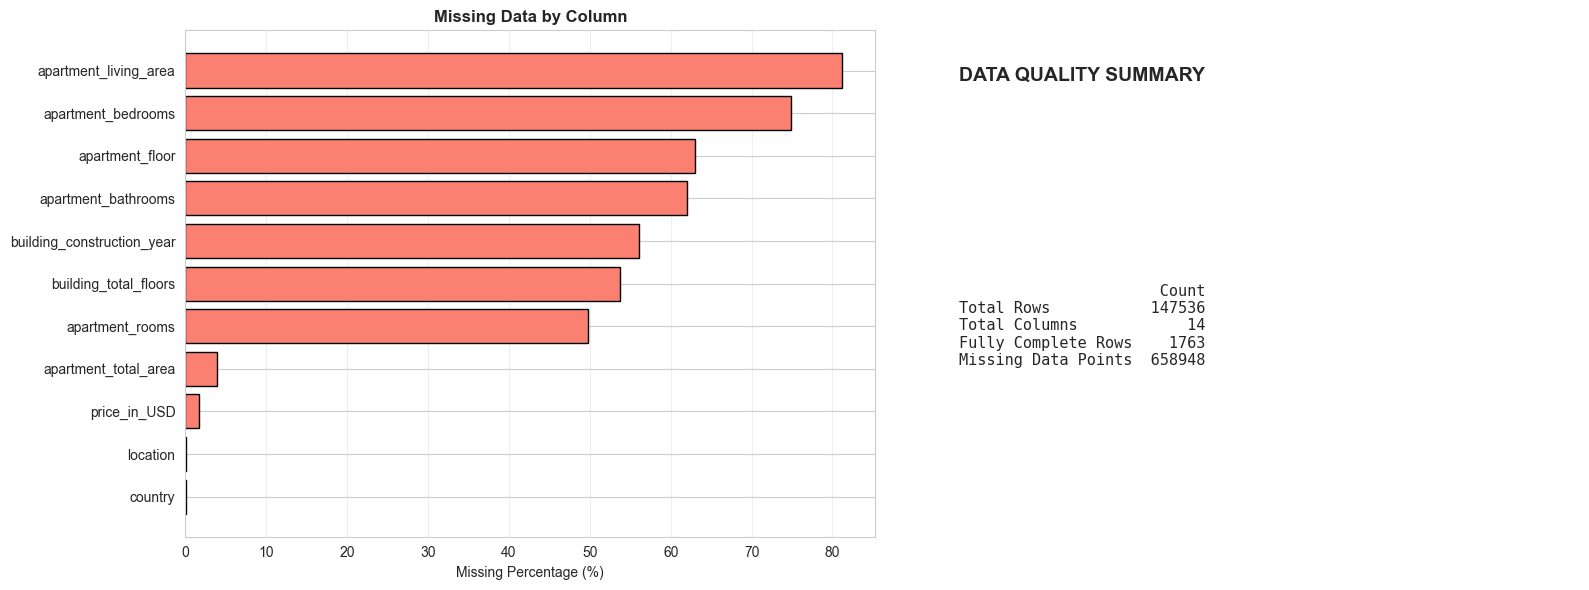

In [3]:
# Analyze missing values (always snapshot the raw view)
source_df = df_raw if 'df_raw' in globals() else df

missing_analysis = pd.DataFrame({
    'Column': source_df.columns,
    'Missing_Count': source_df.isnull().sum().values,
    'Missing_Percent': (source_df.isnull().sum() / len(source_df) * 100).values,
    'Data_Type': source_df.dtypes.values
}).sort_values('Missing_Percent', ascending=False)

print('MISSING VALUES ANALYSIS')

print(missing_analysis.to_string(index=False))

# Visualize missing values
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart of missing data
missing_critical = missing_analysis[missing_analysis['Missing_Percent'] > 0].sort_values('Missing_Percent')
if len(missing_critical) == 0:
    axes[0].text(0.5, 0.5, 'No missing values in selected dataset', ha='center', va='center', fontsize=12)
    axes[0].set_axis_off()
else:
    axes[0].barh(missing_critical['Column'], missing_critical['Missing_Percent'], color='salmon', edgecolor='black')
    axes[0].set_xlabel('Missing Percentage (%)')
    axes[0].set_title('Missing Data by Column', fontweight='bold', fontsize=12)
    axes[0].grid(axis='x', alpha=0.3)

# Summary statistics
summary_data = {
    'Total Rows': [len(source_df)],
    'Total Columns': [len(source_df.columns)],
    'Fully Complete Rows': [source_df.dropna().shape[0]],
    'Missing Data Points': [source_df.isnull().sum().sum()]
}
summary_df = pd.DataFrame(summary_data).T
summary_df.columns = ['Count']
axes[1].axis('off')
axes[1].text(0.1, 0.9, 'DATA QUALITY SUMMARY', fontsize=14, fontweight='bold', 
             transform=axes[1].transAxes)
table_text = summary_df.to_string()
axes[1].text(0.1, 0.5, table_text, fontsize=11, family='monospace',
             transform=axes[1].transAxes, verticalalignment='top')

plt.tight_layout()

# Save the already-plotted figure for the report
from pathlib import Path
PLOT_DIR = Path('plots')
PLOT_DIR.mkdir(exist_ok=True)
plt.savefig(PLOT_DIR / 'MissingValuesBarChart.png', dpi=220, bbox_inches='tight')

plt.show()

## Missing Data Recovery

We noticed that the title field contains valuable information we can extract to fill missing values.
We'll use regex patterns to parse area, rooms, and property type from titles.

In [4]:
# Define function to extract information from title field
def parse_title_full(title):
    """Extract area, rooms, and property type from title string"""
    if not isinstance(title, str) or not title.strip():
        return pd.Series([np.nan, 'other', np.nan, np.nan, np.nan])
    
    raw_title = str(title)
    lower_title = raw_title.lower()
    
    # Extract area (all decimals before m²)
    area_match = re.search(r'(\d[\d.,]*)\s*m²', lower_title)
    area = np.nan
    if area_match:
        try:
            area = float(area_match.group(1).replace(',', ''))
        except ValueError:
            area = np.nan
    
    # Extract room count (decimals before "rooms", "bedrooms")
    # ! limitation sometimes we find bathrooms too but we ignore those for now
    room_match = re.search(r'(\d+(?:\.\d+)?)\s*(?:room|rooms)', lower_title)
    rooms = np.nan
    if room_match:
        try:
            rooms = int(float(room_match.group(1)))
        except ValueError:
            rooms = np.nan

    
    # Identify property type
    property_type = 'other'
    known_types = ['penthouse', 'townhouse', 'bungalow',
                   'apartment', 'duplex', 'triplex', 'cottage', 'mansion',
                   'studio', 'villa', 'house', 'condo', 'chalet',
                     'multilevel']
    
    for ptype in known_types:
        pattern = r'\b' + re.escape(ptype) + r'\b'
        if re.search(pattern, lower_title):
            property_type = ptype
            break
    
    return pd.Series([rooms, property_type, area])

print('Parsing title information...')
df[['parsed_rooms', 'parsed_type', 'parsed_area']] = df['title'].apply(parse_title_full)
print(f'Parsed {len(df)} titles')

Parsing title information...
Parsed 147536 titles


In [5]:
# Clean area columns and remove duplicates
def clean_area(x):
    if pd.isna(x):
        return np.nan
    x = str(x).replace('m²', '').replace(' ', '').strip()
    try:
        return float(x)
    except:
        return np.nan

df['apartment_total_area'] = df['apartment_total_area'].apply(clean_area)
df['apartment_living_area'] = df['apartment_living_area'].apply(clean_area)

In [6]:
# Fill missing values from parsed title data
print('Hierarchical missing value recovery:\n')

# Recover room counts
recovered_rooms = df['apartment_rooms'].isna().sum()
df['apartment_rooms'] = df['apartment_rooms'].fillna(df['parsed_rooms'])
print(f'Recovered {recovered_rooms - df["apartment_rooms"].isna().sum()} room values from titles')

df['property_type'] = df['parsed_type']

Hierarchical missing value recovery:

Recovered 46537 room values from titles


In [7]:
# Bidirectional area estimation between total and living area
# If living area exists but total doesn't, estimate total from living
# If total exists but living doesn't, estimate living from total

print('\nHandling area values with bidirectional estimation...')

recovered_area = df['apartment_total_area'].isna().sum()
df['apartment_total_area'] = df['apartment_total_area'].fillna(df['parsed_area'])
print(f'Recovered {recovered_area - df["apartment_total_area"].isna().sum()} total area values from titles')

# Living → Total estimation (inverse ratio)
has_living_no_total = (df['apartment_living_area'].notna()) & (df['apartment_total_area'].isna())
if has_living_no_total.sum() > 0:
    valid_ratio = (df['apartment_living_area'] / df['apartment_total_area'])[(df['apartment_living_area'].notna()) & (df['apartment_total_area'].notna())]
    median_ratio = valid_ratio.median() if len(valid_ratio) > 0 else 0.85
    recovered_from_living = has_living_no_total.sum()
    df.loc[has_living_no_total, 'apartment_total_area'] = df.loc[has_living_no_total, 'apartment_living_area'] / median_ratio
    print(f'Estimated {recovered_from_living} total area from living area (inverse ratio: {median_ratio:.2f})')

# Total → Living estimation (normal ratio)
has_total_no_living = (df['apartment_total_area'].notna()) & (df['apartment_living_area'].isna())
if has_total_no_living.sum() > 0:
    valid_ratio = (df['apartment_living_area'] / df['apartment_total_area'])[(df['apartment_living_area'].notna()) & (df['apartment_total_area'].notna())]
    median_ratio = valid_ratio.median() if len(valid_ratio) > 0 else 0.85
    recovered_from_total = has_total_no_living.sum()
    df.loc[has_total_no_living, 'apartment_living_area'] = df.loc[has_total_no_living, 'apartment_total_area'] * median_ratio
    print(f'Estimated {recovered_from_total} living area from total area (ratio: {median_ratio:.2f})')

# Drop records with missing critical features
missing_critical = df['apartment_total_area'].isna().sum()
df = df.dropna(subset=['apartment_total_area'])
print(f'\nDropped {missing_critical} records with missing total area')


Handling area values with bidirectional estimation...
Recovered 0 total area values from titles
Estimated 1591 total area from living area (inverse ratio: 0.64)
Estimated 115675 living area from total area (ratio: 0.64)

Dropped 4149 records with missing total area


In [8]:
before_dedup = len(df)
df = df.drop_duplicates()
removed = before_dedup - len(df)
print(f'Removed {removed} duplicate records')

Removed 0 duplicate records


#OUTLIER REMOVAL & CATEGORY CONSOLIDATION

In [9]:
import numpy as np
import pandas as pd

initial_rows = len(df)

cols = ['apartment_rooms', 'apartment_bedrooms', 'apartment_bathrooms']

print('\nInitial missing values:')
print(df[cols].isna().sum())


# Phase 0: Price Tiers (used only for grouping, not values)


df['price_tier'] = pd.qcut(
    df['price_in_USD'],
    q=5,
    duplicates='drop'
)



# Phase 1: Pure Arithmetic Inference


# bedrooms = rooms - bathrooms
mask = (
    df['apartment_bedrooms'].isna() &
    df['apartment_rooms'].notna() &
    df['apartment_bathrooms'].notna()
)
df.loc[mask, 'apartment_bedrooms'] = (
    df.loc[mask, 'apartment_rooms'] -
    df.loc[mask, 'apartment_bathrooms']
).clip(lower=0)

# rooms = bedrooms + bathrooms
mask = (
    df['apartment_rooms'].isna() &
    df['apartment_bedrooms'].notna() &
    df['apartment_bathrooms'].notna()
)
df.loc[mask, 'apartment_rooms'] = (
    df.loc[mask, 'apartment_bedrooms'] +
    df.loc[mask, 'apartment_bathrooms']
)

# bathrooms = rooms - bedrooms
mask = (
    df['apartment_bathrooms'].isna() &
    df['apartment_rooms'].notna() &
    df['apartment_bedrooms'].notna()
)
df.loc[mask, 'apartment_bathrooms'] = (
    df.loc[mask, 'apartment_rooms'] -
    df.loc[mask, 'apartment_bedrooms']
).clip(lower=0)

print('\nAfter arithmetic inference:')
print(df[cols].isna().sum())



# Phase 2: Estimate ROOMS first (hierarchical medians)


room_groups = [
    ['country', 'property_type', 'price_tier'],
    ['property_type', 'price_tier'],
    
]

for g in room_groups:
    if df['apartment_rooms'].isna().any():
        df['apartment_rooms'] = df['apartment_rooms'].fillna(
            df.groupby(g)['apartment_rooms'].transform('median')
        )

print('\nAfter room estimation:')
print(df[cols].isna().sum())



# Phase 3: Estimate BEDROOM RATIO (data-driven)


# Learn bedroom-to-room ratio where both are known
ratio_df = df[
    df['apartment_rooms'].notna() &
    df['apartment_bedrooms'].notna() &
    (df['apartment_rooms'] > 0)
].copy()

ratio_df['bedroom_ratio'] = (
    ratio_df['apartment_bedrooms'] / ratio_df['apartment_rooms']
)

# Compute median ratios by structure
ratio_groups = [
    ['country', 'property_type', 'price_tier'],
    ['property_type', 'price_tier'],
    ['property_type']
]

df['bedroom_ratio'] = np.nan

for g in ratio_groups:
    if df['bedroom_ratio'].isna().any():
        df['bedroom_ratio'] = df['bedroom_ratio'].fillna(
            ratio_df.groupby(g)['bedroom_ratio'].transform('median')
        )

# Global fallback (still data-derived)
global_ratio = ratio_df['bedroom_ratio'].median()
df['bedroom_ratio'] = df['bedroom_ratio'].fillna(global_ratio)



# Phase 4: Infer BEDROOMS from ROOMS


mask = (
    df['apartment_bedrooms'].isna() &
    df['apartment_rooms'].notna()
)

df.loc[mask, 'apartment_bedrooms'] = (
    df.loc[mask, 'apartment_rooms'] *
    df.loc[mask, 'bedroom_ratio']
).round().clip(lower=0)



# Phase 5: Derive BATHROOMS (never median-filled)


mask = (
    df['apartment_bathrooms'].isna() &
    df['apartment_rooms'].notna() &
    df['apartment_bedrooms'].notna()
)

df.loc[mask, 'apartment_bathrooms'] = (
    df.loc[mask, 'apartment_rooms'] -
    df.loc[mask, 'apartment_bedrooms']
).clip(lower=0)



# Phase 6: Validation & Constraints


valid = (
    df['apartment_rooms'].notna() &
    df['apartment_bedrooms'].notna() &
    df['apartment_bathrooms'].notna()
)

overflow = (
    valid &
    (df['apartment_bedrooms'] + df['apartment_bathrooms'] >
     df['apartment_rooms'])
)

df.loc[overflow, 'apartment_bedrooms'] = (
    df.loc[overflow, 'apartment_rooms'] -
    df.loc[overflow, 'apartment_bathrooms']
).clip(lower=0)

print(f'\nAdjusted invalid compositions: {overflow.sum()}')



# Phase 7: Final Casting & Cleanup

for col in cols:
    df[col] = (
        pd.to_numeric(df[col], errors='coerce')
        .round()
        .astype('Int64')
    )

final_missing = df[cols].isna().sum()

print('\nFinal missing values before drop:')
print(final_missing)

df.dropna(subset=cols, inplace=True)

final_rows = len(df)
dropped = initial_rows - final_rows

print('\nSummary:')
print(f'Total rows before: {initial_rows}')
print(f'Total rows after:  {final_rows}')
print(f'Rows dropped:     {dropped} ({dropped / initial_rows:.2%})')



Initial missing values:
apartment_rooms         24108
apartment_bedrooms     107111
apartment_bathrooms     88019
dtype: int64

After arithmetic inference:
apartment_rooms        23382
apartment_bedrooms     82008
apartment_bathrooms    78192
dtype: int64

After room estimation:
apartment_rooms          585
apartment_bedrooms     82008
apartment_bathrooms    78192
dtype: int64

Adjusted invalid compositions: 17887

Final missing values before drop:
apartment_rooms        585
apartment_bedrooms     585
apartment_bathrooms    583
dtype: int64

Summary:
Total rows before: 143387
Total rows after:  142802
Rows dropped:     585 (0.41%)


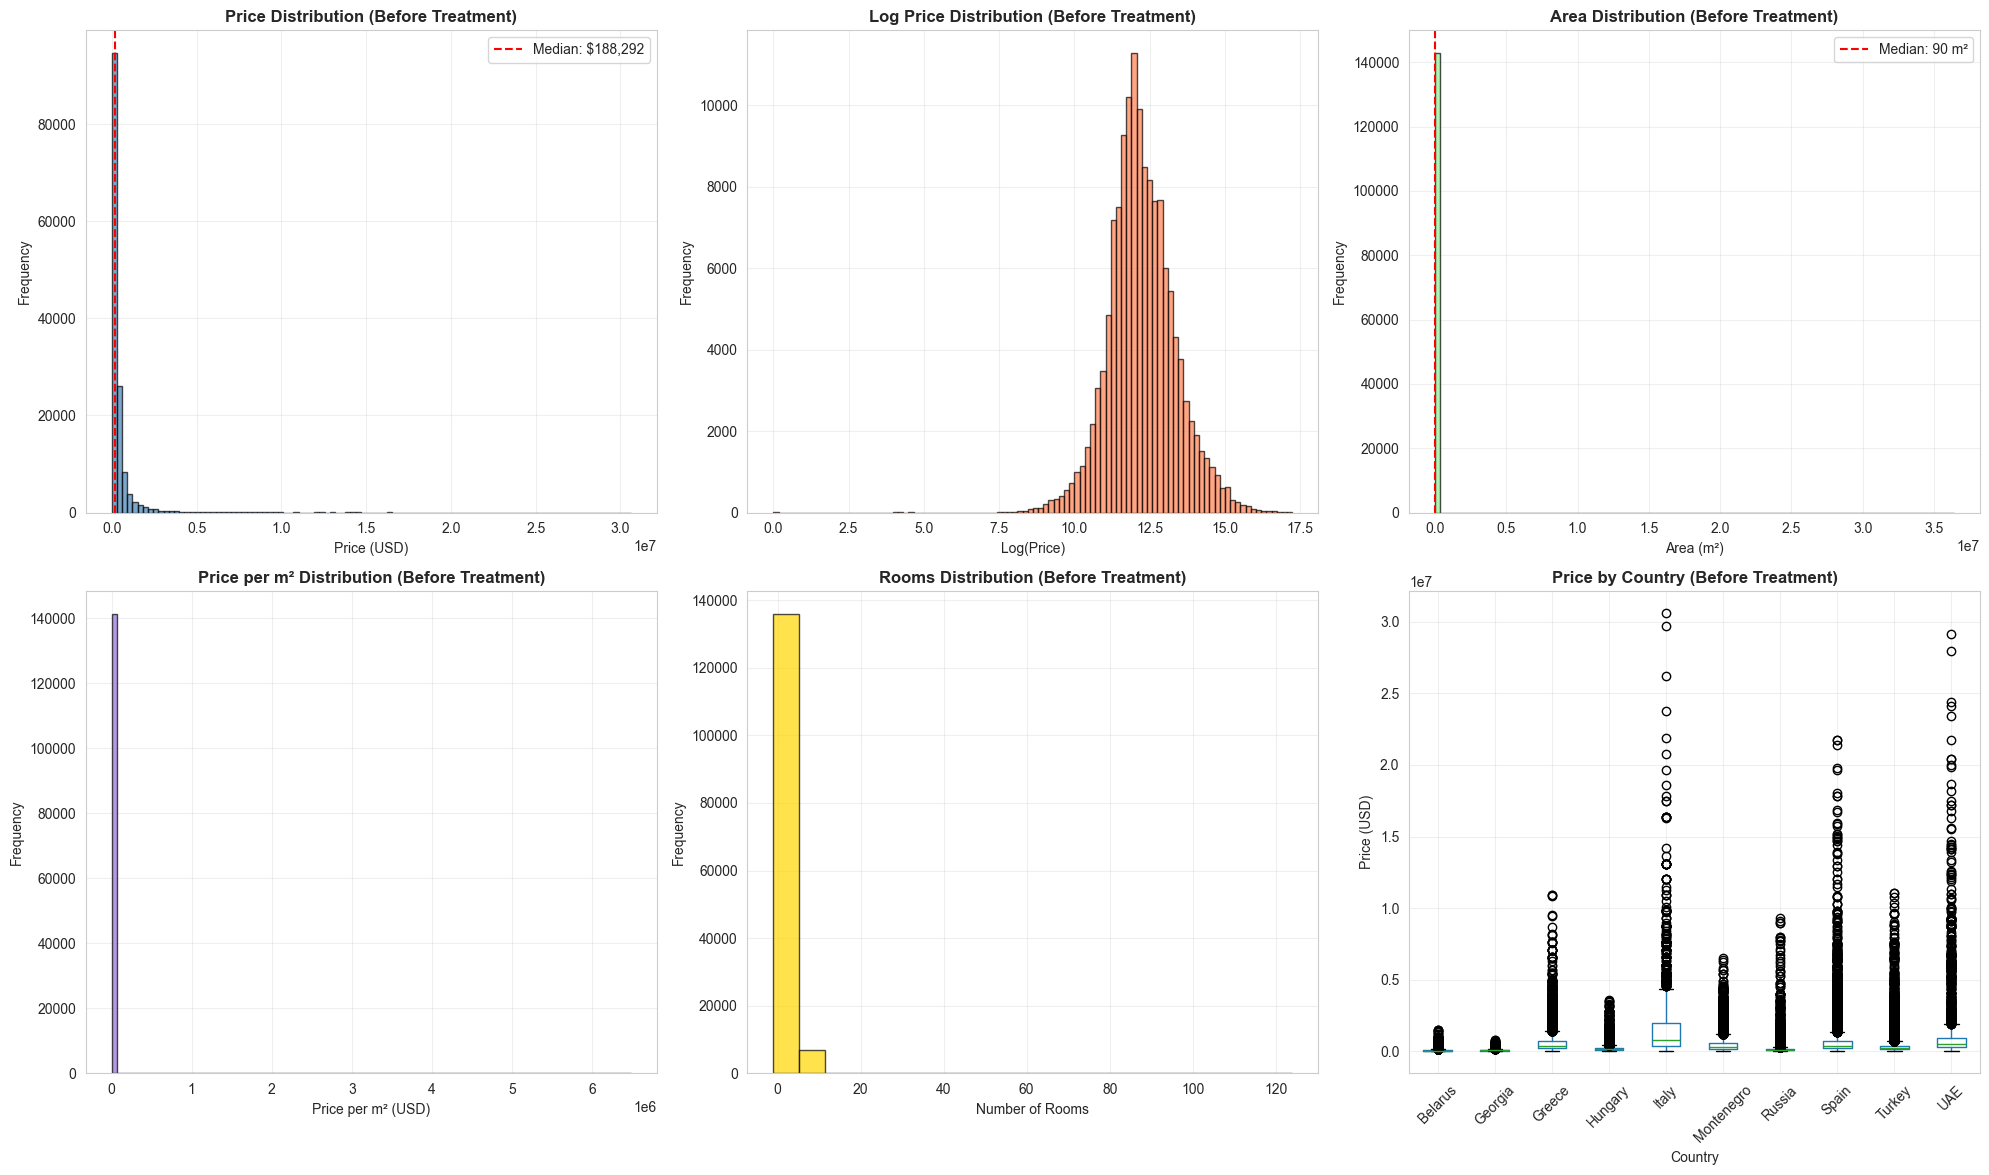

Statistics BEFORE Treatment:
Price: min=$0, max=$30,602,832, median=$188,292
Area: min=1m², max=36405773m², median=90m²
Total records: 142,802


In [10]:
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

PLOT_DIR = Path('plots')
PLOT_DIR.mkdir(exist_ok=True)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Price distribution (original)
axes[0, 0].hist(df['price_in_USD'], bins=100, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Price (USD)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Price Distribution (Before Treatment)', fontweight='bold')
axes[0, 0].axvline(df['price_in_USD'].median(), color='red', linestyle='--', label=f'Median: ${df["price_in_USD"].median():,.0f}')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Price distribution (log scale)
axes[0, 1].hist(np.log1p(df['price_in_USD']), bins=100, color='coral', alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Log(Price)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Log Price Distribution (Before Treatment)', fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# Area distribution
axes[0, 2].hist(df['apartment_total_area'], bins=100, color='lightgreen', alpha=0.7, edgecolor='black')
axes[0, 2].set_xlabel('Area (m²)')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].set_title('Area Distribution (Before Treatment)', fontweight='bold')
axes[0, 2].axvline(df['apartment_total_area'].median(), color='red', linestyle='--', label=f'Median: {df["apartment_total_area"].median():.0f} m²')
axes[0, 2].legend()
axes[0, 2].grid(alpha=0.3)

# Price per sqm
price_per_sqm = df['price_in_USD'] / df['apartment_total_area']
axes[1, 0].hist(price_per_sqm, bins=100, color='mediumpurple', alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('Price per m² (USD)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Price per m² Distribution (Before Treatment)', fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Rooms distribution
axes[1, 1].hist(df['apartment_rooms'], bins=20, color='gold', alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Number of Rooms')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Rooms Distribution (Before Treatment)', fontweight='bold')
axes[1, 1].grid(alpha=0.3)

# Box plot: Price by country (top 10)
top_countries = df['country'].value_counts().head(10).index
df_top = df[df['country'].isin(top_countries)]
df_top.boxplot(column='price_in_USD', by='country', ax=axes[1, 2])
axes[1, 2].set_xlabel('Country')
axes[1, 2].set_ylabel('Price (USD)')
axes[1, 2].set_title('Price by Country (Before Treatment)', fontweight='bold')
axes[1, 2].get_figure().suptitle('')
plt.setp(axes[1, 2].xaxis.get_majorticklabels(), rotation=45)
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'before_treatment_distributions.png', dpi=220, bbox_inches='tight')
plt.show()

print('Statistics BEFORE Treatment:')
print(f'Price: min=${df["price_in_USD"].min():,.0f}, max=${df["price_in_USD"].max():,.0f}, median=${df["price_in_USD"].median():,.0f}')
print(f'Area: min={df["apartment_total_area"].min():.0f}m², max={df["apartment_total_area"].max():.0f}m², median={df["apartment_total_area"].median():.0f}m²')
print(f'Total records: {len(df):,}')

## Price Distribution BEFORE Treatment

In [11]:
# Fill building features using country + price tier, fallback to country
print('\nFilling building features (country + price tier fallback to country):')

building_cols = ['building_construction_year', 'building_total_floors', 'apartment_floor']

for col in building_cols:
    before_fill = df[col].isna().sum()
    
    # Step 1: Fill using country + price tier
    df[col] = df.groupby(['country', 'price_tier'])[col].transform(lambda x: x.fillna(x.median()))
    
    # Step 2: Fallback to country-only median
    df[col] = df.groupby('country')[col].transform(lambda x: x.fillna(x.median()))
    
    # Step 3: Drop remaining missing rows
    after_fill = df[col].isna().sum()
    if after_fill > 0:
        df = df.dropna(subset=[col])
    
    recovered = before_fill - after_fill
    dropped = after_fill
    print(f'{col.replace("_", " ").capitalize()}: recovered {recovered}, dropped {dropped}')

# Clean up temporary columns
df = df.drop(columns=['parsed_rooms', 'parsed_type', 'parsed_area', 'parsed_region', 'parsed_country', 'price_tier'], errors='ignore')

# Final cleanup: drop any remaining rows with missing values
initial_rows = len(df)
df = df.dropna()
final_dropped = initial_rows - len(df)

print(f'\nFinal cleanup: dropped {final_dropped} rows with remaining missing values')
print(f'\nRecovery Complete:')
print(f'  Initial records: {len(df_raw):,}')
print(f'  Final records: {len(df):,}')
print(f'  Retention rate: {len(df)/len(df_raw)*100:.1f}%')



Filling building features (country + price tier fallback to country):
Building construction year: recovered 78791, dropped 652
Building total floors: recovered 74488, dropped 0
Apartment floor: recovered 88012, dropped 0

Final cleanup: dropped 1420 rows with remaining missing values

Recovery Complete:
  Initial records: 147,536
  Final records: 140,730
  Retention rate: 95.4%


In [12]:
# BASIC DATA QUALITY FILTERING ONLY
# Remove extreme outliers that are likely data entry errors

before_outlier_removal = len(df)

# Remove extreme price outliers (99.5th percentile - only clear errors)
price_upper_extreme = df['price_in_USD'].quantile(0.995)
df = df[df['price_in_USD'] <= price_upper_extreme]

# Remove extreme area outliers (properties larger than 1000 m² or smaller than 10 m²)
df = df[(df['apartment_total_area'] >= 10) & (df['apartment_total_area'] <= 1000)]

# PROPERTY TYPE CONSOLIDATION
type_counts = df['property_type'].value_counts()
type_threshold = int(len(df) * 0.01)
low_freq_types = type_counts[type_counts < type_threshold].index
df.loc[df['property_type'].isin(low_freq_types), 'property_type'] = 'others'

# COUNTRY CONSOLIDATION
country_counts = df['country'].value_counts()
country_threshold = int(len(df) * 0.02)
low_freq_countries = country_counts[country_counts < country_threshold].index
df.loc[df['country'].isin(low_freq_countries), 'country'] = 'others'

print(f'Removed {before_outlier_removal - len(df):,} extreme outliers (data errors)')
print(f'Remaining records: {len(df):,}')

Removed 1,566 extreme outliers (data errors)
Remaining records: 139,164


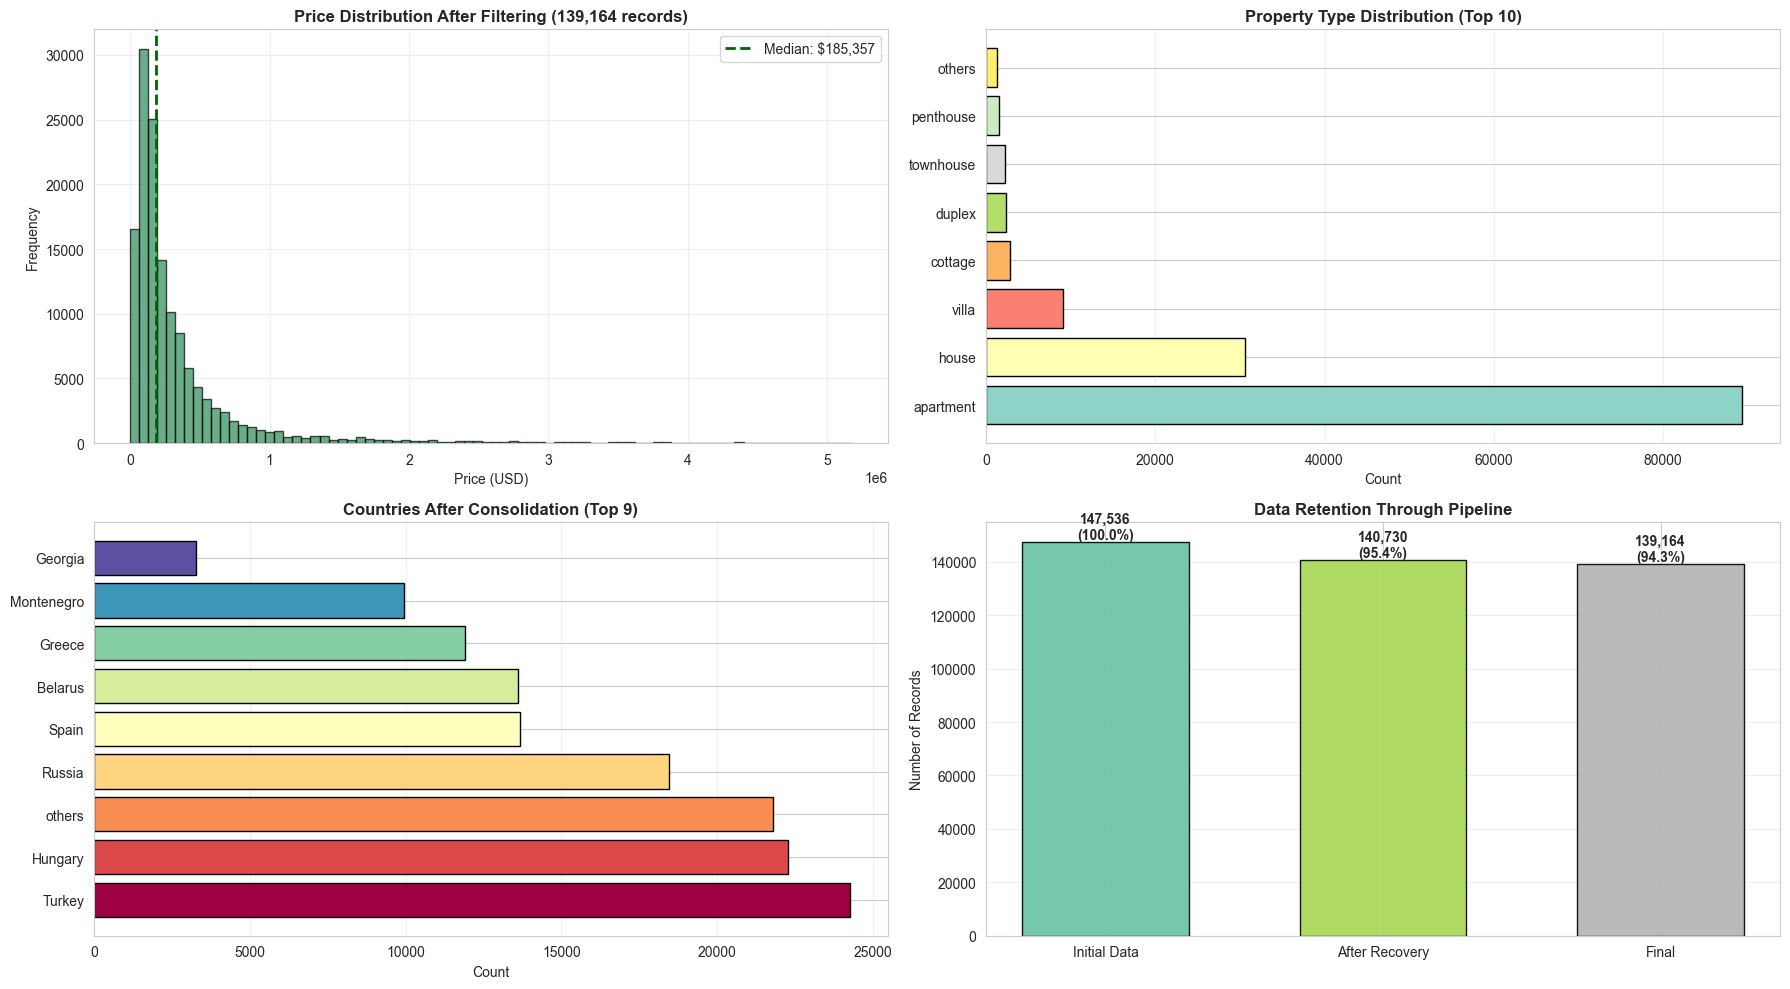

Saved: C:\Users\azizs\Desktop\archive\plots\outlier_and_consolidation_overview.png


In [13]:
# Visualize outlier removal and consolidation results (and save for report)
from pathlib import Path

PLOT_DIR = Path('plots')
PLOT_DIR.mkdir(exist_ok=True)

# Recompute post-consolidation country counts (the consolidation happens in the cell above)
country_counts_after = df['country'].value_counts().head(15)

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# Price distribution after filtering
axes[0, 0].hist(df['price_in_USD'], bins=80, alpha=0.7, color='seagreen', edgecolor='black')
axes[0, 0].axvline(df['price_in_USD'].median(), color='darkgreen', linestyle='--', linewidth=2, 
           label=f'Median: ${df["price_in_USD"].median():,.0f}')
axes[0, 0].set_xlabel('Price (USD)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title(f'Price Distribution After Filtering ({len(df):,} records)', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Property type distribution
type_counts_sorted = df['property_type'].value_counts().head(10)
axes[0, 1].barh(range(len(type_counts_sorted)), type_counts_sorted.values, color=plt.cm.Set3(np.linspace(0, 1, len(type_counts_sorted))), edgecolor='black')
axes[0, 1].set_yticks(range(len(type_counts_sorted)))
axes[0, 1].set_yticklabels(type_counts_sorted.index)
axes[0, 1].set_xlabel('Count')
axes[0, 1].set_title('Property Type Distribution (Top 10)', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='x')

# Country distribution after consolidation
colors_after = plt.cm.Spectral(np.linspace(0, 1, len(country_counts_after)))
axes[1, 0].barh(range(len(country_counts_after)), country_counts_after.values, color=colors_after, edgecolor='black')
axes[1, 0].set_yticks(range(len(country_counts_after)))
axes[1, 0].set_yticklabels(country_counts_after.index)
axes[1, 0].set_xlabel('Count')
axes[1, 0].set_title(f'Countries After Consolidation (Top {len(country_counts_after)})', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='x')

# Data retention through pipeline
retention_data = {'Initial Data': len(df_raw), 'After Recovery': before_outlier_removal, 'Final': len(df)}
stages = list(retention_data.keys())
records = list(retention_data.values())
retention_colors = plt.cm.Set2(np.linspace(0, 1, len(stages)))
axes[1, 1].bar(stages, records, color=retention_colors, edgecolor='black', width=0.6, alpha=0.9)
axes[1, 1].set_ylabel('Number of Records')
axes[1, 1].set_title('Data Retention Through Pipeline', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')
for i, (stage, count) in enumerate(zip(stages, records)):
    pct = (count / len(df_raw)) * 100
    axes[1, 1].text(i, count, f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()

out_path = PLOT_DIR / 'outlier_and_consolidation_overview.png'
plt.savefig(out_path, dpi=220, bbox_inches='tight')
plt.show()

print(f'Saved: {out_path.resolve()}')

## Five Independent Preprocessing Approaches for Modeling

Each approach applies its OWN outlier treatment from the cleaned base data.
No approach builds on top of another.

In [14]:
from scipy import stats

preprocessing_approaches = {}

# APPROACH 1: Percentile Capping + Log Transform
print('='*80)
print('APPROACH 1: Percentile Capping (1%-99%) + Log Transform')
print('='*80)
df_approach1 = df.copy()

# Cap price at 1% and 99%
price_lower_p = df_approach1['price_in_USD'].quantile(0.01)
price_upper_p = df_approach1['price_in_USD'].quantile(0.99)
df_approach1 = df_approach1[(df_approach1['price_in_USD'] >= price_lower_p) & 
                             (df_approach1['price_in_USD'] <= price_upper_p)]

# Cap area by property type
for prop_type in df_approach1['property_type'].unique():
    mask = df_approach1['property_type'] == prop_type
    if mask.sum() > 50:
        lower = df_approach1.loc[mask, 'apartment_total_area'].quantile(0.01)
        upper = df_approach1.loc[mask, 'apartment_total_area'].quantile(0.99)
        df_approach1 = df_approach1[~mask | ((df_approach1['apartment_total_area'] >= lower) & 
                                              (df_approach1['apartment_total_area'] <= upper))]

# Apply log transforms
df_approach1['price_log'] = np.log1p(df_approach1['price_in_USD'])
df_approach1['area_log'] = np.log1p(df_approach1['apartment_total_area'])

print(f'Records: {len(df_approach1):,}')
print(f'Price range: ${df_approach1["price_in_USD"].min():,.0f} - ${df_approach1["price_in_USD"].max():,.0f}')
print(f'Area range: {df_approach1["apartment_total_area"].min():.0f} - {df_approach1["apartment_total_area"].max():.0f} m²')

preprocessing_approaches['approach1_percentile_log'] = df_approach1

APPROACH 1: Percentile Capping (1%-99%) + Log Transform
Records: 133,743
Price range: $14,000 - $2,870,216
Area range: 22 - 800 m²


In [15]:
# APPROACH 2: IQR-Based Outlier Removal + Log Transform
print('\n' + '='*80)
print('APPROACH 2: IQR-Based Outlier Removal + Log Transform')
print('='*80)
df_approach2 = df.copy()

# Price IQR filtering
price_q1 = df_approach2['price_in_USD'].quantile(0.25)
price_q3 = df_approach2['price_in_USD'].quantile(0.75)
price_iqr = price_q3 - price_q1
price_lower = max(1000, price_q1 - 1.5 * price_iqr)
price_upper = price_q3 + 1.5 * price_iqr
df_approach2 = df_approach2[(df_approach2['price_in_USD'] >= price_lower) & 
                             (df_approach2['price_in_USD'] <= price_upper)]

# Area IQR filtering by property type
for prop_type in df_approach2['property_type'].unique():
    mask = df_approach2['property_type'] == prop_type
    if mask.sum() > 50:
        area_q1 = df_approach2.loc[mask, 'apartment_total_area'].quantile(0.25)
        area_q3 = df_approach2.loc[mask, 'apartment_total_area'].quantile(0.75)
        area_iqr = area_q3 - area_q1
        area_lower = max(10, area_q1 - 1.5 * area_iqr)
        area_upper = area_q3 + 1.5 * area_iqr
        df_approach2 = df_approach2[~mask | ((df_approach2['apartment_total_area'] >= area_lower) & 
                                              (df_approach2['apartment_total_area'] <= area_upper))]

# Apply log transforms
df_approach2['price_log'] = np.log1p(df_approach2['price_in_USD'])
df_approach2['area_log'] = np.log1p(df_approach2['apartment_total_area'])

print(f'Records: {len(df_approach2):,}')
print(f'Price range: ${df_approach2["price_in_USD"].min():,.0f} - ${df_approach2["price_in_USD"].max():,.0f}')
print(f'Area range: {df_approach2["apartment_total_area"].min():.0f} - {df_approach2["apartment_total_area"].max():.0f} m²')

preprocessing_approaches['approach2_iqr_log'] = df_approach2


APPROACH 2: IQR-Based Outlier Removal + Log Transform
Records: 119,999
Price range: $1,712 - $801,607
Area range: 10 - 476 m²


In [16]:
# APPROACH 3: Minimal Capping (5%-95%) + Raw Values
print('\n' + '='*80)
print('APPROACH 3: Minimal Capping (5%-95%) + Raw Values (No Log)')
print('='*80)
df_approach3 = df.copy()

# Minimal percentile filtering
price_lower_min = df_approach3['price_in_USD'].quantile(0.05)
price_upper_min = df_approach3['price_in_USD'].quantile(0.95)
df_approach3 = df_approach3[(df_approach3['price_in_USD'] >= price_lower_min) & 
                             (df_approach3['price_in_USD'] <= price_upper_min)]

# Area filtering by property type
for prop_type in df_approach3['property_type'].unique():
    mask = df_approach3['property_type'] == prop_type
    if mask.sum() > 50:
        lower = df_approach3.loc[mask, 'apartment_total_area'].quantile(0.05)
        upper = df_approach3.loc[mask, 'apartment_total_area'].quantile(0.95)
        df_approach3 = df_approach3[~mask | ((df_approach3['apartment_total_area'] >= lower) & 
                                              (df_approach3['apartment_total_area'] <= upper))]

print(f'Records: {len(df_approach3):,}')
print(f'Price range: ${df_approach3["price_in_USD"].min():,.0f} - ${df_approach3["price_in_USD"].max():,.0f}')
print(f'Area range: {df_approach3["apartment_total_area"].min():.0f} - {df_approach3["apartment_total_area"].max():.0f} m²')

preprocessing_approaches['approach3_minimal_raw'] = df_approach3


# APPROACH 4: Z-Score Based Filtering + Raw Values
print('\n' + '='*80)
print('APPROACH 4: Z-Score Based Filtering (|z| < 3) + Raw Values')
print('='*80)
df_approach4 = df.copy()

# Remove outliers using z-score
z_price = np.abs(stats.zscore(df_approach4['price_in_USD']))
z_area = np.abs(stats.zscore(df_approach4['apartment_total_area']))
df_approach4 = df_approach4[(z_price < 3) & (z_area < 3)]

print(f'Records: {len(df_approach4):,}')
print(f'Price range: ${df_approach4["price_in_USD"].min():,.0f} - ${df_approach4["price_in_USD"].max():,.0f}')
print(f'Area range: {df_approach4["apartment_total_area"].min():.0f} - {df_approach4["apartment_total_area"].max():.0f} m²')

preprocessing_approaches['approach4_zscore_raw'] = df_approach4


# APPROACH 5: No Additional Filtering + Robust Scaling Features
print('\n' + '='*80)
print('APPROACH 5: No Additional Filtering (Keep All Data)')
print('='*80)
df_approach5 = df.copy()

print(f'Records: {len(df_approach5):,}')
print(f'Price range: ${df_approach5["price_in_USD"].min():,.0f} - ${df_approach5["price_in_USD"].max():,.0f}')
print(f'Area range: {df_approach5["apartment_total_area"].min():.0f} - {df_approach5["apartment_total_area"].max():.0f} m²')

preprocessing_approaches['approach5_no_filtering'] = df_approach5


print(f'Five independent preprocessing approaches created successfully')



APPROACH 3: Minimal Capping (5%-95%) + Raw Values (No Log)
Records: 112,851
Price range: $37,934 - $1,298,879
Area range: 30 - 484 m²

APPROACH 4: Z-Score Based Filtering (|z| < 3) + Raw Values
Records: 133,663
Price range: $0 - $1,924,950
Area range: 10 - 479 m²

APPROACH 5: No Additional Filtering (Keep All Data)
Records: 139,164
Price range: $0 - $5,174,495
Area range: 10 - 1000 m²
Five independent preprocessing approaches created successfully


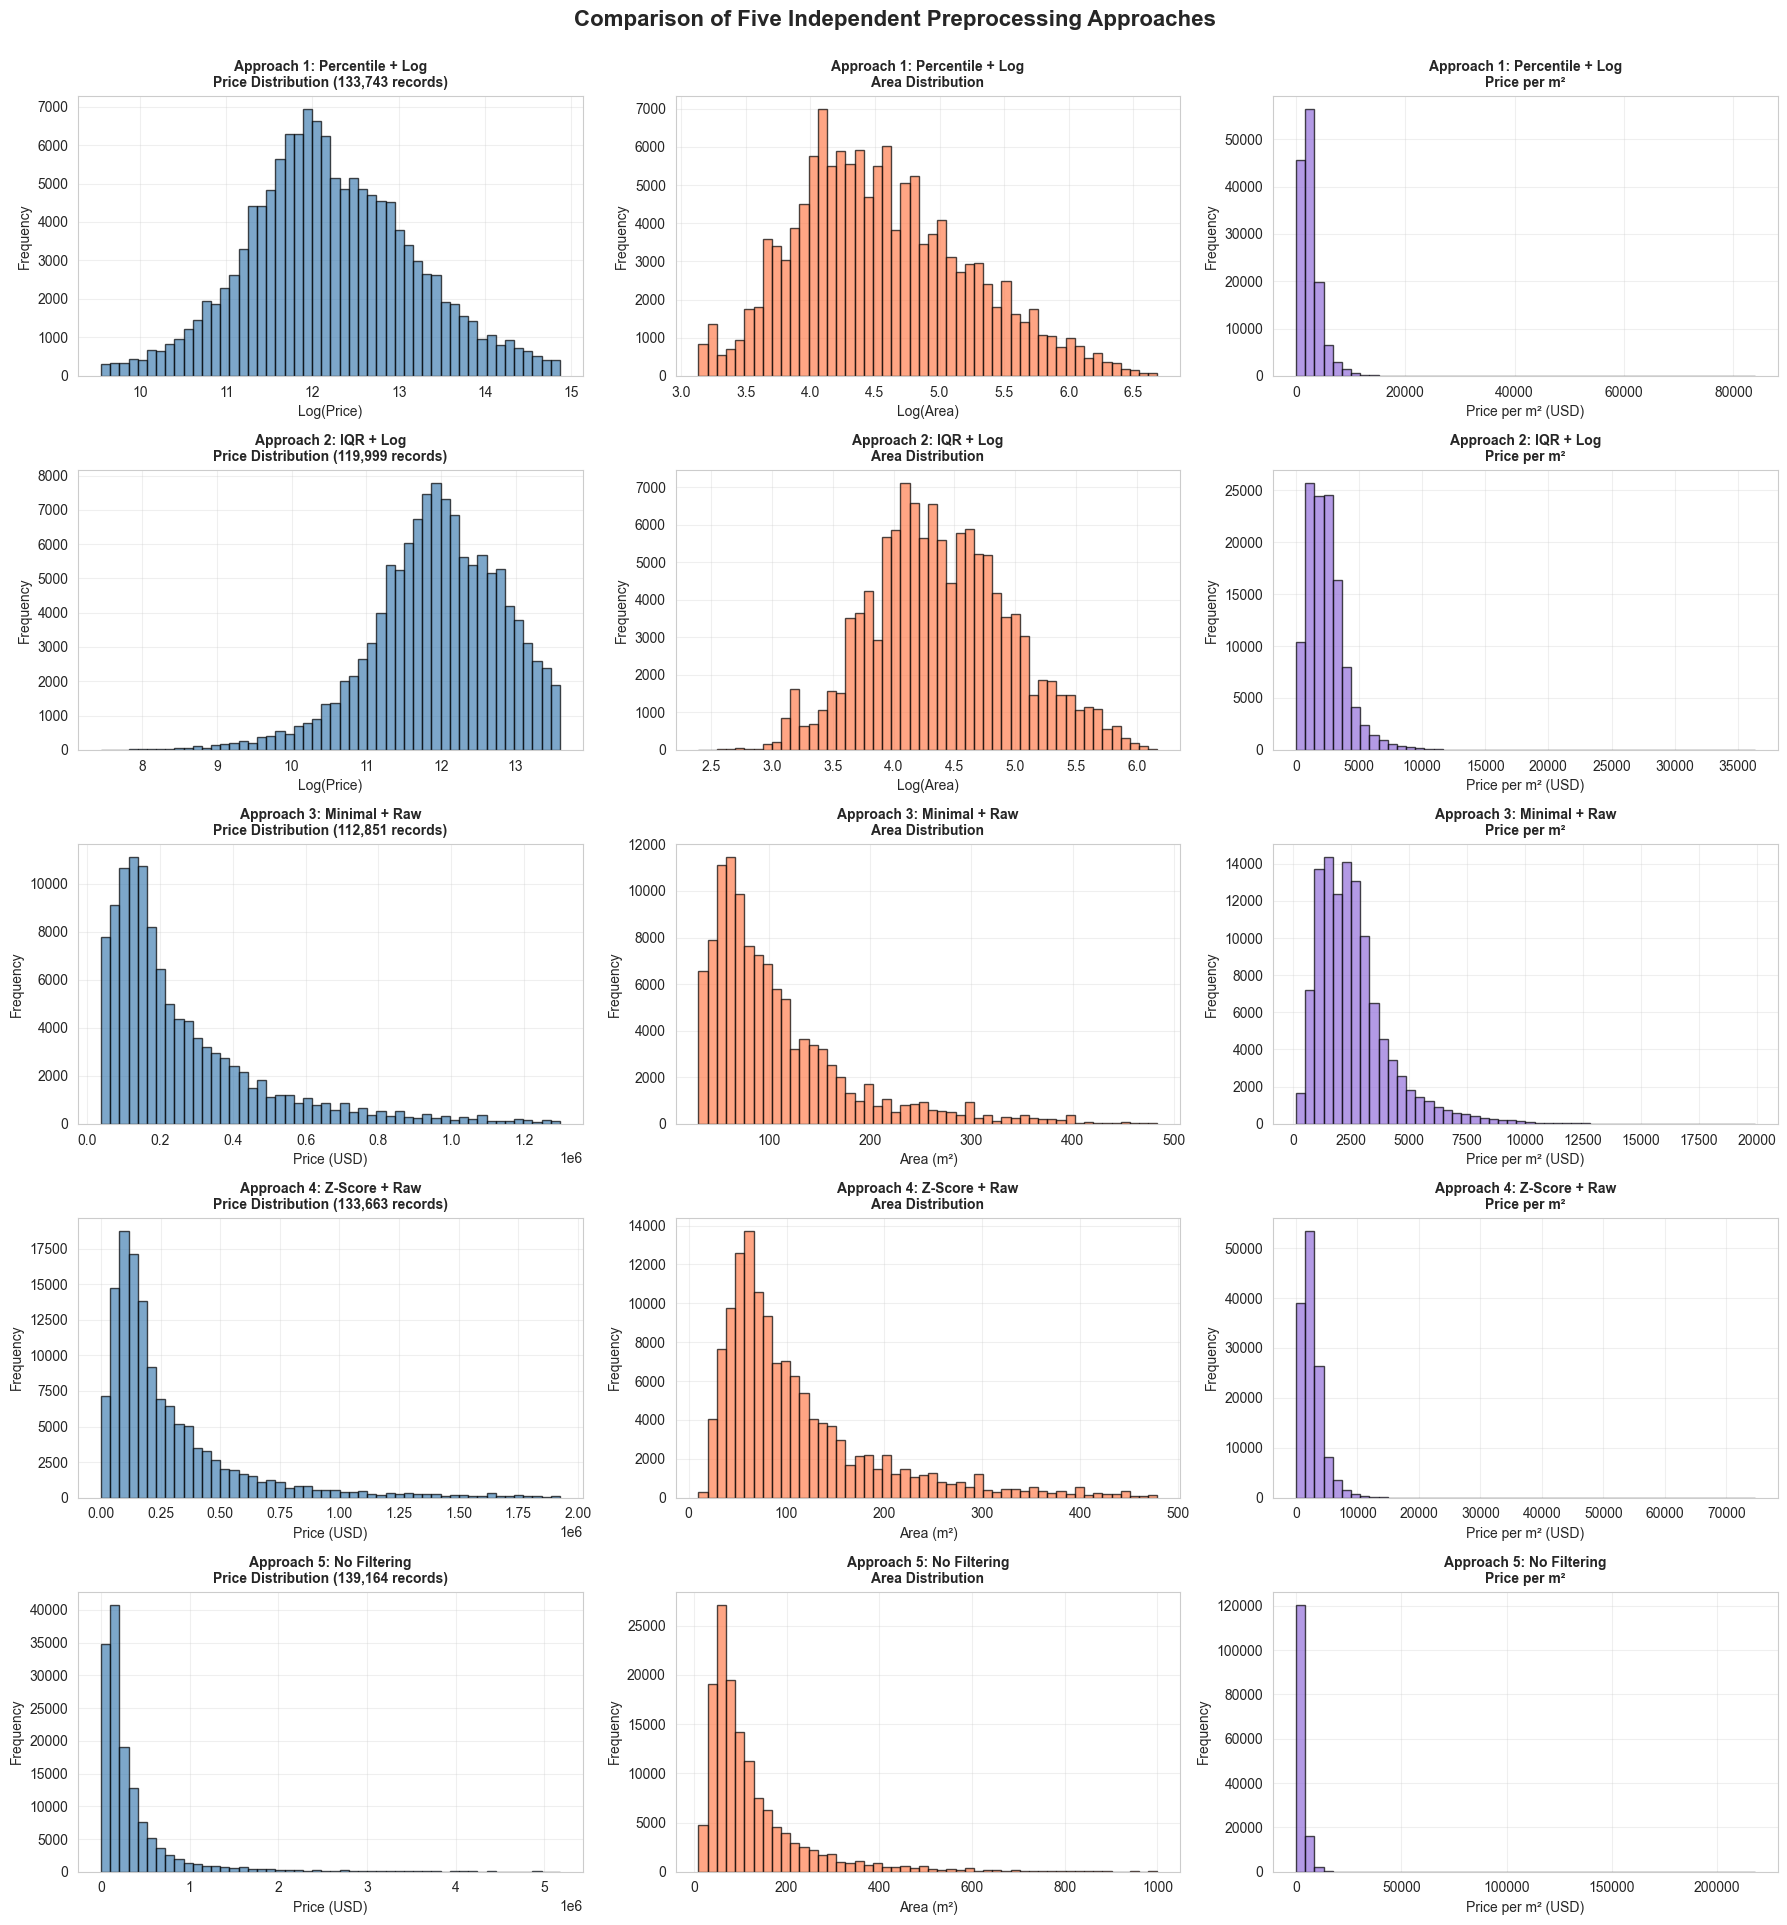

In [17]:
from pathlib import Path

PLOT_DIR = Path('plots')
PLOT_DIR.mkdir(exist_ok=True)

fig, axes = plt.subplots(5, 3, figsize=(18, 20))
fig.suptitle('Comparison of Five Independent Preprocessing Approaches', fontsize=16, fontweight='bold')

approaches = [
    ('Approach 1: Percentile + Log', df_approach1, True),
    ('Approach 2: IQR + Log', df_approach2, True),
    ('Approach 3: Minimal + Raw', df_approach3, False),
    ('Approach 4: Z-Score + Raw', df_approach4, False),
    ('Approach 5: No Filtering', df_approach5, False),
]

for row_idx, (approach_name, df_approach, has_log) in enumerate(approaches):
    # Price distribution
    ax = axes[row_idx, 0]
    if has_log and 'price_log' in df_approach.columns:
        ax.hist(df_approach['price_log'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
        ax.set_xlabel('Log(Price)')
    else:
        ax.hist(df_approach['price_in_USD'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
        ax.set_xlabel('Price (USD)')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{approach_name}\nPrice Distribution ({len(df_approach):,} records)', fontweight='bold', fontsize=10)
    ax.grid(True, alpha=0.3)

    # Area distribution
    ax = axes[row_idx, 1]
    if has_log and 'area_log' in df_approach.columns:
        ax.hist(df_approach['area_log'], bins=50, color='coral', alpha=0.7, edgecolor='black')
        ax.set_xlabel('Log(Area)')
    else:
        ax.hist(df_approach['apartment_total_area'], bins=50, color='coral', alpha=0.7, edgecolor='black')
        ax.set_xlabel('Area (m²)')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{approach_name}\nArea Distribution', fontweight='bold', fontsize=10)
    ax.grid(True, alpha=0.3)

    # Price per sqm distribution
    ax = axes[row_idx, 2]
    price_per_sqm = df_approach['price_in_USD'] / df_approach['apartment_total_area']
    ax.hist(price_per_sqm, bins=50, color='mediumpurple', alpha=0.7, edgecolor='black')
    ax.set_xlabel('Price per m² (USD)')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{approach_name}\nPrice per m²', fontweight='bold', fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0.02, 1, 0.98])
plt.savefig(PLOT_DIR / 'approaches_comparison.png', dpi=220, bbox_inches='tight')
plt.show()

EXPORTING PREPROCESSED DATASETS

Approach 1: Percentile + Log:
Saved: preprocessed_data\real_estate_approach1_percentile_log_top8.csv (133,743 records, 12 columns)
Top numeric: ['apartment_living_area', 'apartment_rooms', 'apartment_bedrooms', 'bedroom_ratio', 'apartment_bathrooms', 'building_total_floors', 'apartment_floor', 'building_construction_year']

Approach 2: IQR + Log:
Saved: preprocessed_data\real_estate_approach2_iqr_log_top8.csv (119,999 records, 12 columns)
Top numeric: ['apartment_living_area', 'apartment_rooms', 'apartment_bedrooms', 'bedroom_ratio', 'apartment_bathrooms', 'building_total_floors', 'apartment_floor', 'building_construction_year']

Approach 3: Minimal + Raw:
Saved: preprocessed_data\real_estate_approach3_minimal_raw_top8.csv (112,851 records, 12 columns)
Top numeric: ['apartment_living_area', 'apartment_rooms', 'apartment_bedrooms', 'bedroom_ratio', 'apartment_bathrooms', 'building_total_floors', 'apartment_floor', 'building_construction_year']

Approach 

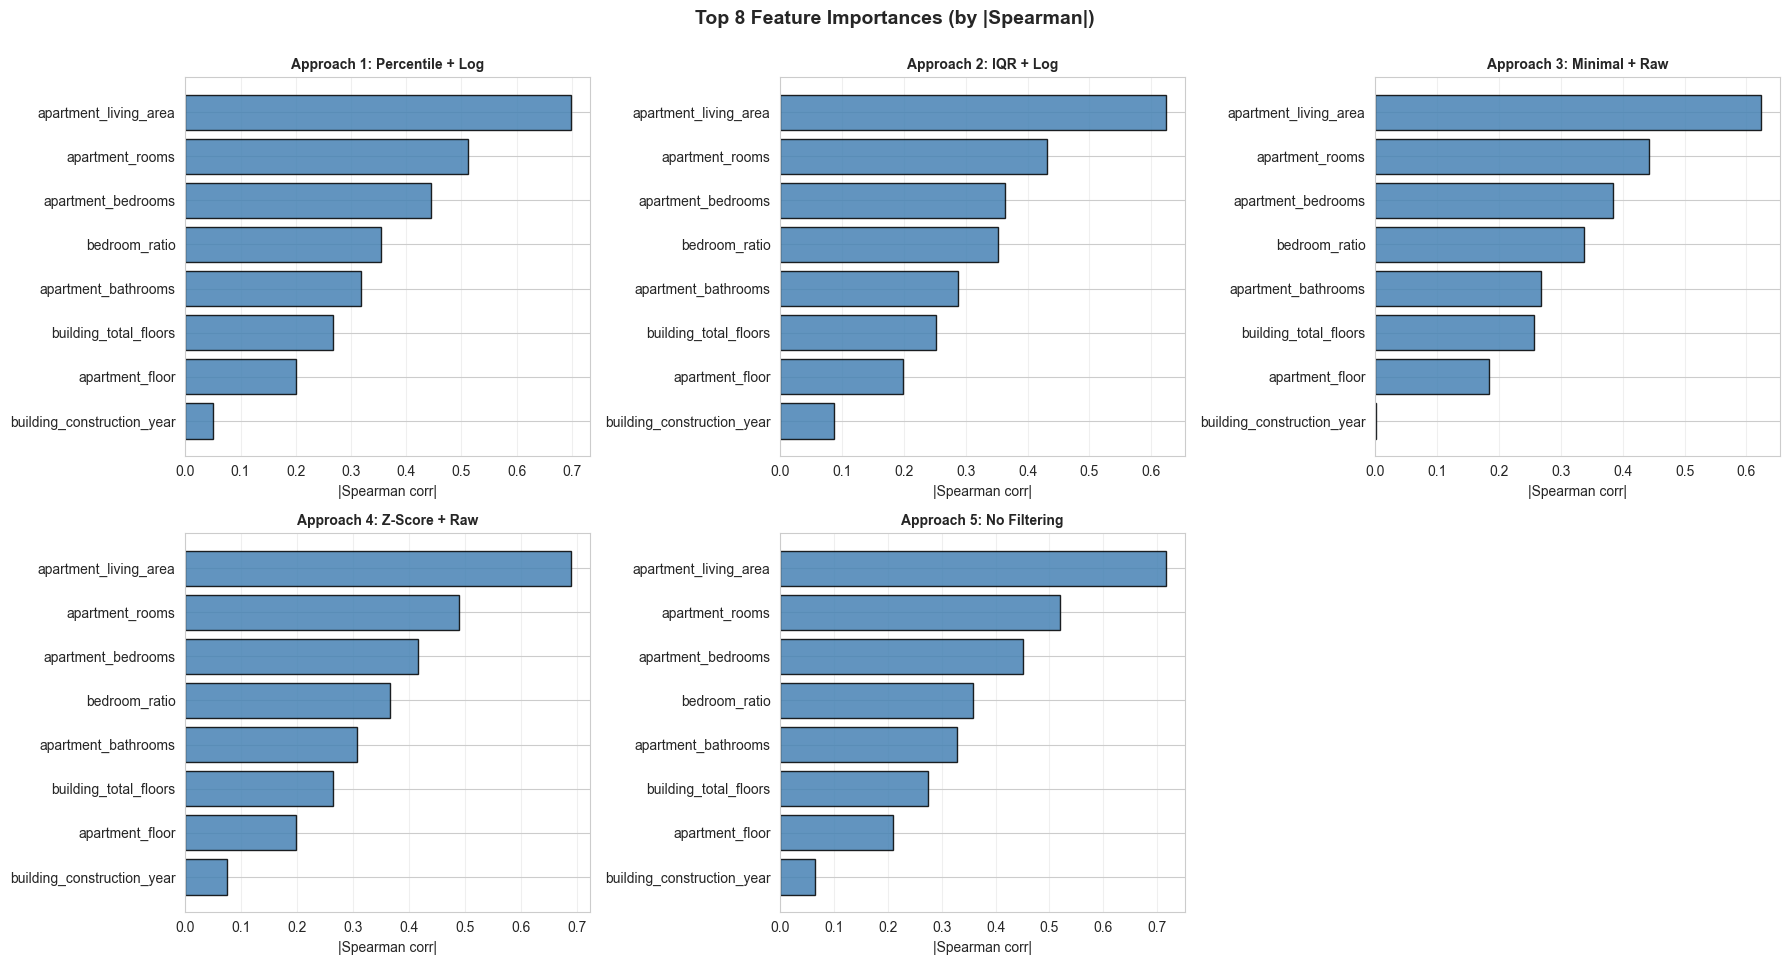

In [18]:
import os
from pathlib import Path
import matplotlib.pyplot as plt

export_dir = 'preprocessed_data'
os.makedirs(export_dir, exist_ok=True)

PLOT_DIR = Path('plots')
PLOT_DIR.mkdir(exist_ok=True)

TARGET_COL = 'price_in_USD'
TOP_N = 8

# Columns to never export
DROP_NON_FEATURES = {'title', 'image', 'url'}

# Prevent data leakage
LEAKAGE_COLS = {'price_capped', 'price_log', 'price_per_sqm', 'price_per_sqm_capped'}

# Always keep these
ALWAYS_KEEP = ['country', 'location', 'property_type']

# Redundancy groups
REDUNDANCY_GROUPS = [
    {'apartment_total_area', 'apartment_living_area', 'area_log'},
    {'apartment_rooms', 'apartment_rooms_capped'},
    {'apartment_bathrooms', 'apartment_bathrooms_capped'},
]


def _drop_price_leakage_cols(cols):
    cleaned = []
    for c in cols:
        if c in LEAKAGE_COLS:
            continue
        if c.startswith('price_') and c != TARGET_COL:
            continue
        cleaned.append(c)
    return cleaned


def _feature_group(feature: str) -> int | None:
    for idx, group in enumerate(REDUNDANCY_GROUPS):
        if feature in group:
            return idx
    return None


def _spearman_scores(df_in: pd.DataFrame, target_col: str) -> dict[str, float]:
    if target_col not in df_in.columns:
        raise ValueError(f"Target column '{target_col}' not found.")

    y = df_in[target_col]
    numeric_cols = df_in.select_dtypes(include=['number']).columns.tolist()
    numeric_cols = [c for c in numeric_cols if c != target_col]
    numeric_cols = [c for c in numeric_cols if c not in DROP_NON_FEATURES]
    numeric_cols = _drop_price_leakage_cols(numeric_cols)

    scores: dict[str, float] = {}
    for c in numeric_cols:
        try:
            corr = df_in[c].corr(y, method='spearman')
        except Exception:
            corr = None
        if corr is None or pd.isna(corr):
            continue
        scores[c] = abs(float(corr))

    return scores


def _select_top_nonredundant(scores: dict[str, float], top_n: int) -> list[str]:
    ranked = sorted(scores.items(), key=lambda t: t[1], reverse=True)
    selected: list[str] = []
    used_groups: set[int] = set()

    for feat, _score in ranked:
        group_id = _feature_group(feat)
        if group_id is not None and group_id in used_groups:
            continue
        selected.append(feat)
        if group_id is not None:
            used_groups.add(group_id)
        if len(selected) >= top_n:
            break

    return selected


def _export_top_features(df_in: pd.DataFrame, filename: str, top_n: int = TOP_N):
    cols = [c for c in df_in.columns if c not in DROP_NON_FEATURES]
    cols = _drop_price_leakage_cols(cols)
    df_work = df_in[cols].copy()

    scores = _spearman_scores(df_work, TARGET_COL)
    top_numeric = _select_top_nonredundant(scores, top_n=top_n)

    keep_cats = [c for c in ALWAYS_KEEP if c in df_work.columns]

    export_cols = []
    export_cols.extend(keep_cats)
    export_cols.extend([c for c in top_numeric if c not in export_cols])
    export_cols.append(TARGET_COL)

    df_out = df_work[export_cols].copy()
    df_out.to_csv(filename, index=False)
    
    print(f"Saved: {filename} ({len(df_out):,} records, {len(df_out.columns)} columns)")
    print(f'Top numeric: {top_numeric}')

    return df_out, top_numeric, scores


# Export all 5 approaches
exports = [
    ('Approach 1: Percentile + Log', df_approach1, f'real_estate_approach1_percentile_log_top{TOP_N}.csv'),
    ('Approach 2: IQR + Log', df_approach2, f'real_estate_approach2_iqr_log_top{TOP_N}.csv'),
    ('Approach 3: Minimal + Raw', df_approach3, f'real_estate_approach3_minimal_raw_top{TOP_N}.csv'),
    ('Approach 4: Z-Score + Raw', df_approach4, f'real_estate_approach4_zscore_raw_top{TOP_N}.csv'),
    ('Approach 5: No Filtering', df_approach5, f'real_estate_approach5_no_filtering_top{TOP_N}.csv'),
]

export_results: dict[str, dict] = {}

print('='*80)
print('EXPORTING PREPROCESSED DATASETS')
print('='*80)

for name, df_src, fname in exports:
    print(f'\n{name}:')
    out_path = os.path.join(export_dir, fname)
    df_out, top_numeric, scores = _export_top_features(df_src, out_path)
    export_results[name] = {
        'path': out_path,
        'df': df_out,
        'top_numeric': top_numeric,
        'scores': scores,
    }


print('All datasets exported successfully')

summary_df = pd.DataFrame({
    'Approach': [name for name, *_ in exports],
    'Records': [len(export_results[name]['df']) for name, *_ in exports],
    'Features': [len(export_results[name]['df'].columns) for name, *_ in exports],
})
print('\n' + summary_df.to_string(index=False))


# Plot feature importance comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, (name, *_rest) in enumerate(exports):
    if idx >= len(axes):
        break
    
    top_feats = export_results[name]['top_numeric']
    scores = export_results[name]['scores']
    
    vals = [scores.get(f, 0.0) for f in top_feats]
    order = sorted(range(len(top_feats)), key=lambda i: vals[i])
    disp_feats = [top_feats[i] for i in order]
    disp_vals = [vals[i] for i in order]
    
    axes[idx].barh(disp_feats, disp_vals, color='steelblue', edgecolor='black', alpha=0.85)
    axes[idx].set_title(name, fontweight='bold', fontsize=10)
    axes[idx].set_xlabel('|Spearman corr|')
    axes[idx].grid(axis='x', alpha=0.3)

# Hide extra subplot
if len(exports) < len(axes):
    axes[-1].set_visible(False)

fig.suptitle(f'Top {TOP_N} Feature Importances (by |Spearman|)', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.02, 1, 0.98])
plt.savefig(PLOT_DIR / f'top_features_spearman_top{TOP_N}.png', dpi=220, bbox_inches='tight')
plt.show()

## Price Analysis by Country and Region

TOP 20 COUNTRIES BY PROPERTY COUNT
            Median_Price  Mean_Price  Count  Min_Price  Max_Price  Std_Price  Median_Area
country                                                                                  
Turkey          206094.0    357285.0  24262    15985.0  5134902.0   469558.0        105.0
Hungary         142297.0    201956.0  22264        0.0  3564566.0   212760.0         89.0
others          285482.0    514653.0  21789       61.0  5172601.0   673490.0         92.0
Russia          131530.0    182469.0  18438     6127.0  4796167.0   253911.0         52.0
Spain           380425.0    618985.0  13679    32696.0  5174495.0   682076.0        117.0
Belarus          50900.0     71947.0  13621     1900.0  1500000.0    86697.0         61.0
Greece          402163.0    623967.0  11906    30434.0  5027608.0   677780.0        160.0
Montenegro      304340.0    504771.0   9946    35869.0  4891177.0   604043.0        116.0
Georgia          68575.0     93673.0   3259    19500.0   827253.0

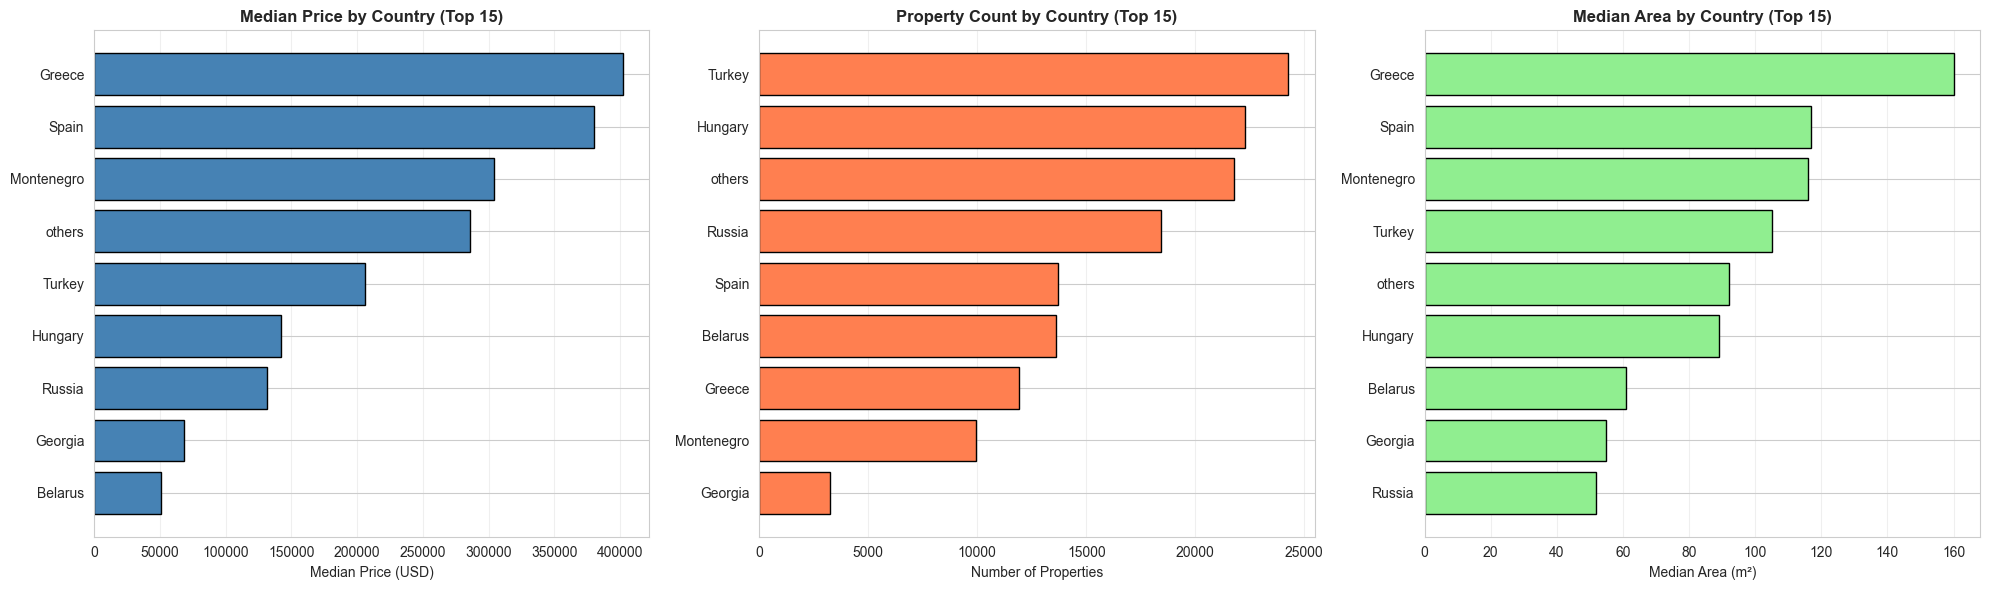

In [19]:
# Analyze median prices by country
price_by_country = df.groupby('country').agg({
    'price_in_USD': ['median', 'mean', 'count', 'min', 'max', 'std'],
    'apartment_total_area': 'median'
}).round(0)

price_by_country.columns = ['Median_Price', 'Mean_Price', 'Count', 'Min_Price', 'Max_Price', 'Std_Price', 'Median_Area']
price_by_country = price_by_country.sort_values('Count', ascending=False)

print('TOP 20 COUNTRIES BY PROPERTY COUNT')
print('='*100)
print(price_by_country.head(20).to_string())

top_countries = price_by_country.head(15).index.tolist()

# Visualize key metrics by country
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Median prices
top_prices = price_by_country.head(15).sort_values('Median_Price', ascending=True)
axes[0].barh(range(len(top_prices)), top_prices['Median_Price'], color='steelblue', edgecolor='black')
axes[0].set_yticks(range(len(top_prices)))
axes[0].set_yticklabels(top_prices.index)
axes[0].set_xlabel('Median Price (USD)')
axes[0].set_title('Median Price by Country (Top 15)', fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Property counts
top_counts = price_by_country.head(15).sort_values('Count', ascending=True)
axes[1].barh(range(len(top_counts)), top_counts['Count'], color='coral', edgecolor='black')
axes[1].set_yticks(range(len(top_counts)))
axes[1].set_yticklabels(top_counts.index)
axes[1].set_xlabel('Number of Properties')
axes[1].set_title('Property Count by Country (Top 15)', fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

# Median area
top_area = price_by_country.head(15).sort_values('Median_Area', ascending=True)
axes[2].barh(range(len(top_area)), top_area['Median_Area'], color='lightgreen', edgecolor='black')
axes[2].set_yticks(range(len(top_area)))
axes[2].set_yticklabels(top_area.index)
axes[2].set_xlabel('Median Area (m²)')
axes[2].set_title('Median Area by Country (Top 15)', fontweight='bold')
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

PRICE ANALYSIS BY REGION (Top 5 Countries)

Turkey - Top Regions:
                                                    Median_Price  Mean_Price  Count  Median_Area
location                                                                                        
Aegean Region, Icmeler Mahallesi, Urla, Turkey         2615789.0   2762806.0      6        432.0
Aegean Coast, Bodrum, Turkey                           2020000.0   2117500.0      6        234.0
Bozhane Mahallesi, Marmara Region, Turkey              1826039.0   2032419.0      5        286.0
Dagbelen, Aegean Region, Bodrum, Turkey                1739085.0   1820002.0     78        216.0
Fatih, Marmara Region, Turkey                          1608654.0   1313473.0     25        210.0
Bitez, Aegean Region, Bodrum, Turkey                   1548855.0   1673016.0     53        190.0
Aegean Region, Celal Bayar Mahallesi, Turkey           1344787.0   1319644.0      5        208.0
Yalikavak, Aegean Region, Bodrum, Turkey               129539

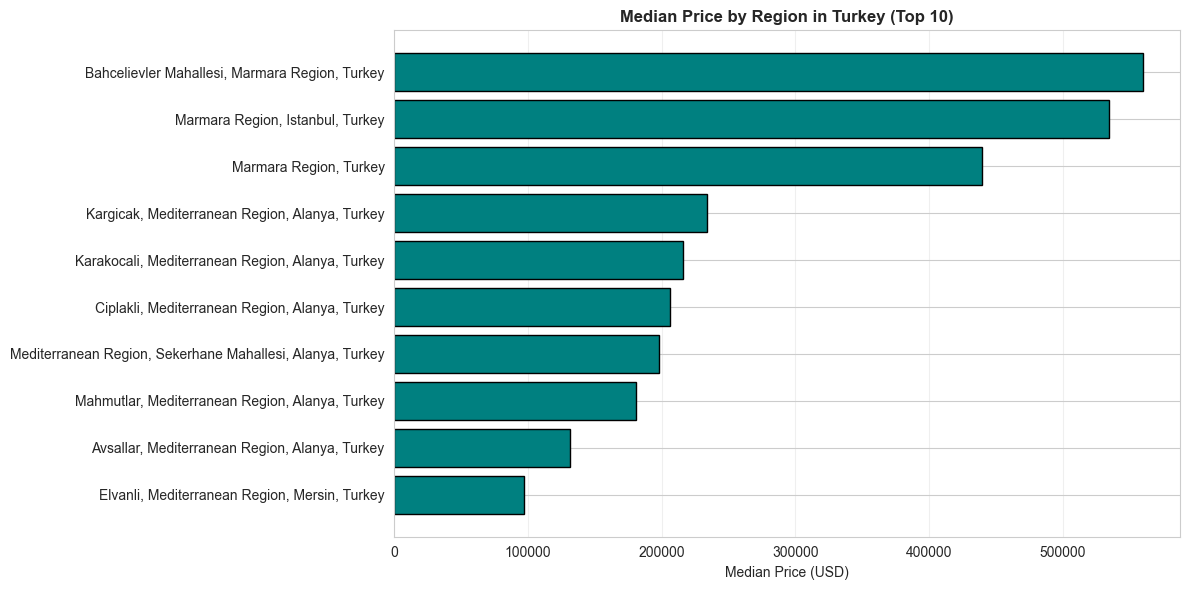

In [20]:
# Regional price analysis within top countries
print('PRICE ANALYSIS BY REGION (Top 5 Countries)')
print('='*100)

for country in top_countries[:5]:
    country_data = df[df['country'] == country]
    region_prices = country_data.groupby('location').agg({
        'price_in_USD': ['median', 'mean', 'count'],
        'apartment_total_area': 'median'
    }).round(0)
    region_prices.columns = ['Median_Price', 'Mean_Price', 'Count', 'Median_Area']
    region_prices = region_prices[region_prices['Count'] >= 5].sort_values('Median_Price', ascending=False)

    print(f'\n{country} - Top Regions:')
    print(region_prices.head(10).to_string())

# Visualize regional differences for top country
if len(top_countries) > 0:
    top_country = top_countries[0]
    country_data = df[df['country'] == top_country]
    top_regions = country_data['location'].value_counts().head(10).index.tolist()

    fig, ax = plt.subplots(1, 1, figsize=(12, 6))

    region_prices_all = country_data[country_data['location'].isin(top_regions)].groupby('location').agg({
        'price_in_USD': ['median', 'count']
    }).round(0)
    region_prices_all.columns = ['Median_Price', 'Count']
    region_prices_all = region_prices_all.sort_values('Median_Price', ascending=True)

    ax.barh(range(len(region_prices_all)), region_prices_all['Median_Price'], color='teal', edgecolor='black')
    ax.set_yticks(range(len(region_prices_all)))
    ax.set_yticklabels(region_prices_all.index)
    ax.set_xlabel('Median Price (USD)')
    ax.set_title(f'Median Price by Region in {top_country} (Top 10)', fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

## Feature Expectations by Price Range

Understanding what features are typical at different price points helps set realistic expectations.

FEATURE EXPECTATIONS BY PRICE TIER
        Tier           Price Range  Count  Avg_Area_sqm  Avg_Rooms  Avg_Bedrooms  Avg_Bathrooms  Avg_Floor  Avg_Building_Age  Avg_Price_per_sqm
      Budget         $0 - $103,454  34791     62.061600   2.168089      1.241930       0.926332   4.867609         25.355537        1307.536282
   Mid-Range   $103,454 - $185,357  34750     80.720173   2.545496      1.503597       1.042906   4.792777         27.877885        2197.814374
     Premium   $185,357 - $382,764  34832    123.898964   3.208802      1.952400       1.260651   3.388522         26.084836        2726.738938
      Luxury   $382,764 - $779,519  20874    184.076452   3.669924      2.326962       1.353789   3.333908         16.056625        3744.125511
Ultra-Luxury $779,519 - $5,174,495  13916    326.183140   4.335801      2.815967       1.538229   3.138546         12.527594        5884.029888


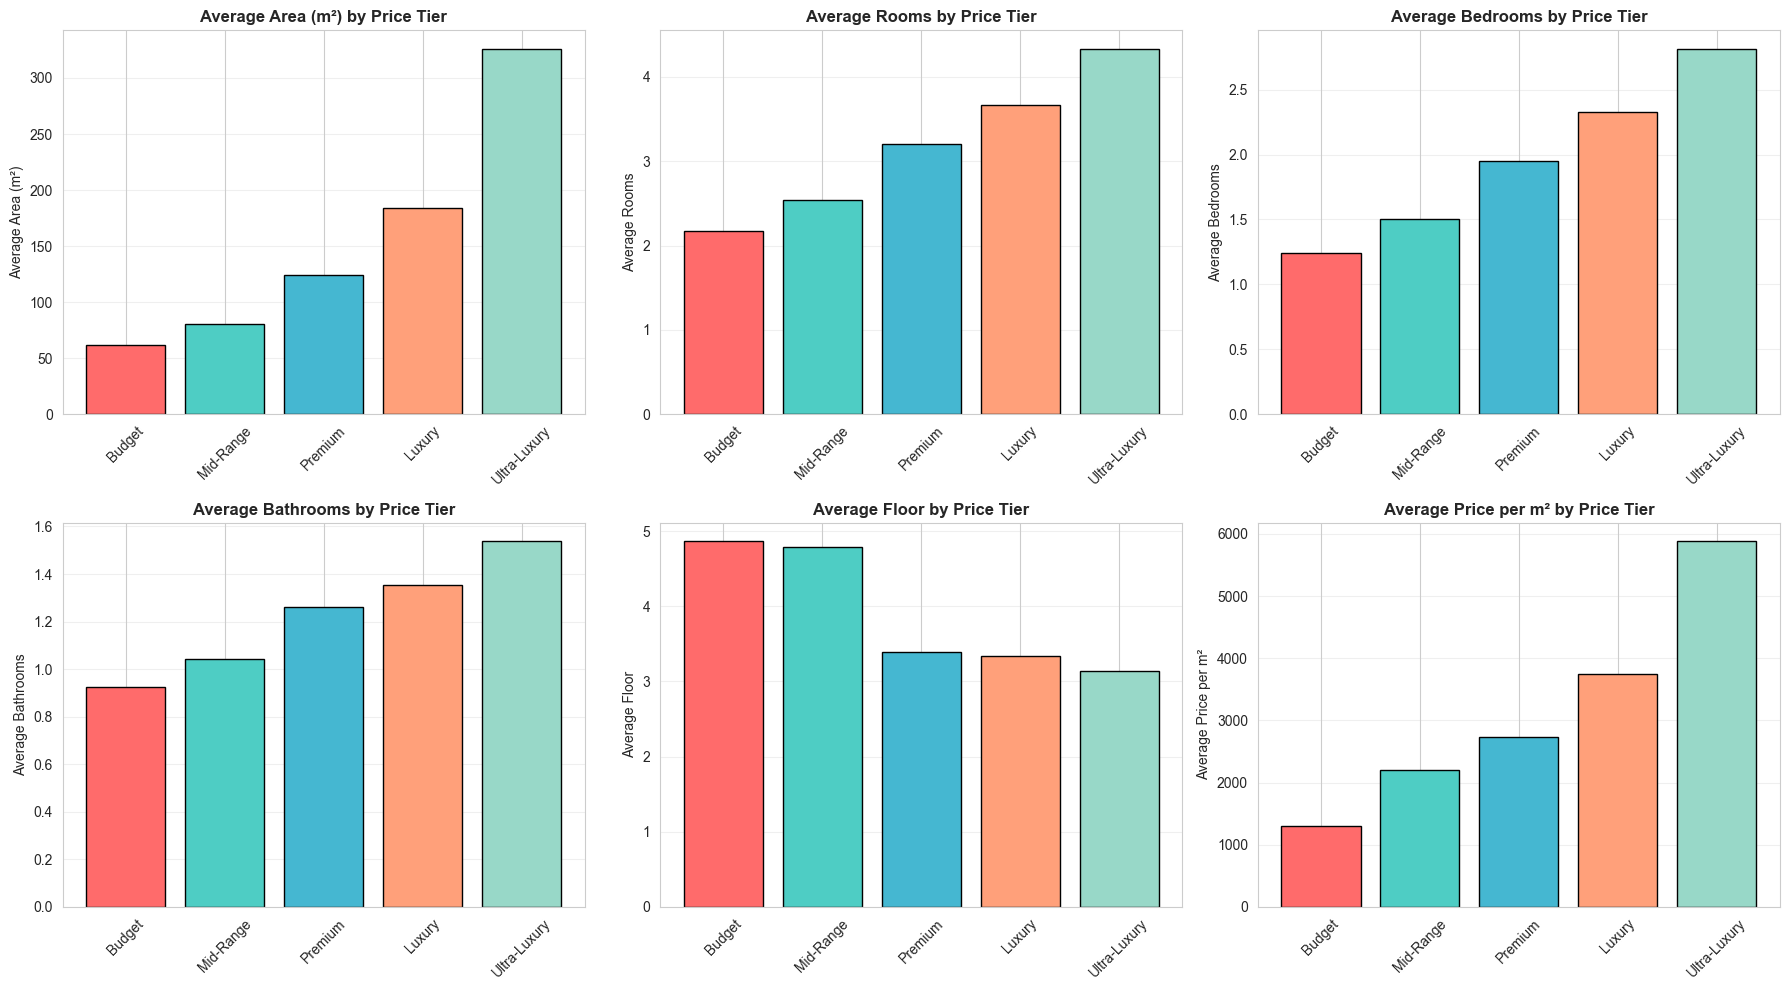

In [21]:
# Define price tiers based on quantiles
q1 = df['price_in_USD'].quantile(0.25)
q2 = df['price_in_USD'].quantile(0.50)
q3 = df['price_in_USD'].quantile(0.75)
q4 = df['price_in_USD'].quantile(0.90)

price_tiers = {
    'Budget': (0, q1),
    'Mid-Range': (q1, q2),
    'Premium': (q2, q3),
    'Luxury': (q3, q4),
    'Ultra-Luxury': (q4, df['price_in_USD'].max())
}

# Analyze features for each tier
feature_analysis = []
for tier, (min_price, max_price) in price_tiers.items():
    tier_data = df[(df['price_in_USD'] >= min_price) & (df['price_in_USD'] < max_price)]
    feature_stats = {
        'Tier': tier,
        'Price Range': f'${min_price:,.0f} - ${max_price:,.0f}',
        'Count': len(tier_data),
        'Avg_Area_sqm': tier_data['apartment_total_area'].mean(),
        'Avg_Rooms': tier_data['apartment_rooms'].mean(),
        'Avg_Bedrooms': tier_data['apartment_bedrooms'].mean(),
        'Avg_Bathrooms': tier_data['apartment_bathrooms'].mean(),
        'Avg_Floor': tier_data['apartment_floor'].mean(),
        'Avg_Building_Age': 2026 - tier_data['building_construction_year'].mean(),
        'Avg_Price_per_sqm': (tier_data['price_in_USD'] / tier_data['apartment_total_area']).mean()
    }
    feature_analysis.append(feature_stats)

feature_df = pd.DataFrame(feature_analysis)
print('FEATURE EXPECTATIONS BY PRICE TIER')
print('='*140)
print(feature_df.to_string(index=False))

# Visualize feature comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
feature_cols = ['Avg_Area_sqm', 'Avg_Rooms', 'Avg_Bedrooms', 'Avg_Bathrooms', 'Avg_Floor', 'Avg_Price_per_sqm']
titles = ['Average Area (m²)', 'Average Rooms', 'Average Bedrooms', 'Average Bathrooms', 'Average Floor', 'Average Price per m²']

for idx, (col, title) in enumerate(zip(feature_cols, titles)):
    ax = axes[idx // 3, idx % 3]
    ax.bar(
        feature_df['Tier'],
        feature_df[col],
        color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8'],
        edgecolor='black'
    )
    ax.set_ylabel(title)
    ax.set_title(f'{title} by Price Tier', fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()

# Save for the report
from pathlib import Path
PLOT_DIR = Path('plots')
PLOT_DIR.mkdir(exist_ok=True)
plt.savefig(PLOT_DIR / 'feature_expectations_by_price_tier.png', dpi=220, bbox_inches='tight')

plt.show()

## Section 6: Before vs After Data Quality Comparison

Compare dataset quality before and after recovery/cleaning


📊 DATA QUALITY: BEFORE vs AFTER
                     Metric        Before    After         Change  % Change
              Total Records 147536.000000 139164.0   -8372.000000      -5.7
          Duplicate Records      0.000000      0.0       0.000000       NaN
  Records with Missing Area   5740.000000      0.0   -5740.000000    -100.0
 Records with Missing Rooms  73358.000000      0.0  -73358.000000    -100.0
   Rows Usable for Analysis   1763.000000 139164.0  137401.000000    7793.6
Missing Data Points (Total) 658948.000000      0.0 -658948.000000    -100.0
        Avg Missing per Row      4.466354      0.0      -4.466354    -100.0


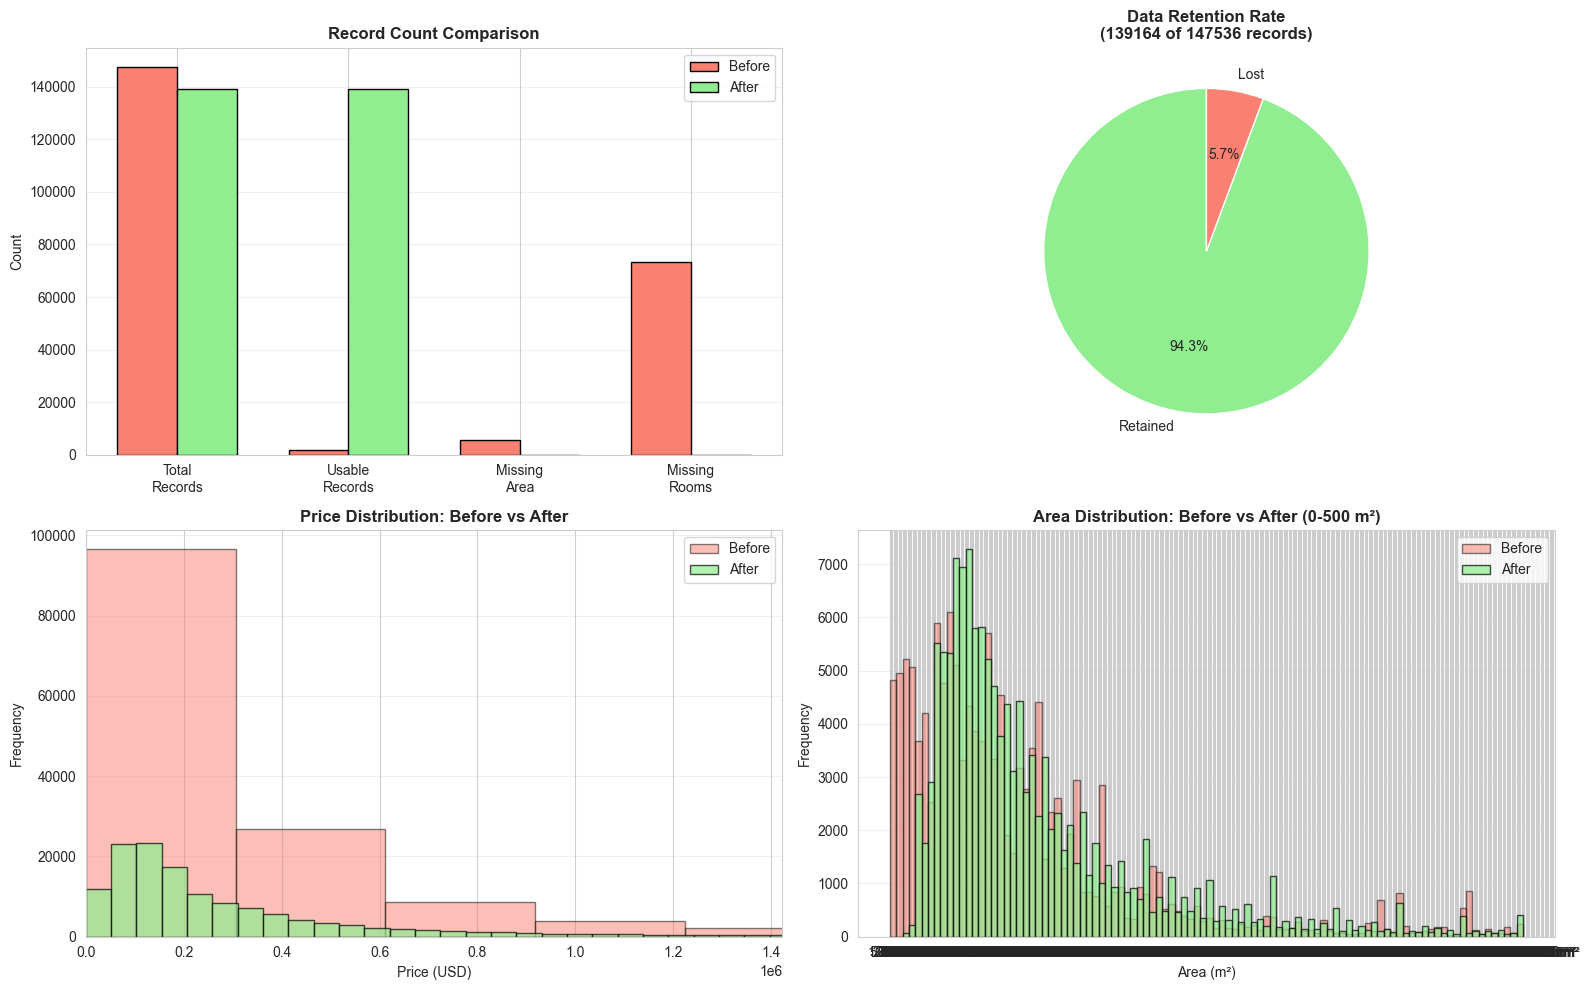


✅ Data Recovery Summary:
   • Started with: 147,536 records
   • Recovered and retained: 139,164 records (94.3%)
   • Total missing values eliminated: 658,948
   • Data completeness improved from 68.1% to 100.0%


In [22]:
# Before vs after analysis
before_stats = {
    'Metric': ['Total Records', 'Duplicate Records', 'Records with Missing Area', 'Records with Missing Rooms',
               'Rows Usable for Analysis', 'Missing Data Points (Total)', 'Avg Missing per Row'],
    'Before': [
        len(df_raw),
        len(df_raw) - len(df_raw.drop_duplicates()),
        df_raw['apartment_total_area'].isna().sum(),
        df_raw['apartment_rooms'].isna().sum(),
        len(df_raw.dropna()),
        df_raw.isnull().sum().sum(),
        df_raw.isnull().sum().sum() / len(df_raw)
    ]
}

after_stats = pd.DataFrame(before_stats)
after_stats['After'] = [
    len(df),
    0,  # Duplicates removed
    0,  # No missing areas
    0,  # No missing rooms
    len(df.dropna()),
    df.isnull().sum().sum(),
    df.isnull().sum().sum() / len(df) if len(df) > 0 else 0
]

after_stats['Change'] = after_stats['After'] - after_stats['Before']
after_stats['% Change'] = (after_stats['Change'] / after_stats['Before'] * 100).round(1)

print('\n📊 DATA QUALITY: BEFORE vs AFTER')
print('='*120)
print(after_stats.to_string(index=False))

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Record count comparison
categories = ['Total\nRecords', 'Usable\nRecords', 'Missing\nArea', 'Missing\nRooms']
before_vals = [len(df_raw), len(df_raw.dropna()), df_raw['apartment_total_area'].isna().sum(), 
               df_raw['apartment_rooms'].isna().sum()]
after_vals = [len(df), len(df.dropna()), df['apartment_total_area'].isna().sum(), 
              df['apartment_rooms'].isna().sum()]

x = np.arange(len(categories))
width = 0.35

axes[0, 0].bar(x - width/2, before_vals, width, label='Before', color='salmon', edgecolor='black')
axes[0, 0].bar(x + width/2, after_vals, width, label='After', color='lightgreen', edgecolor='black')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Record Count Comparison', fontweight='bold', fontsize=12)
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(categories)
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Data retention rate
retention_categories = ['Retained', 'Lost']
retained = len(df) / len(df_raw) * 100
lost = 100 - retained

axes[0, 1].pie([retained, lost], labels=retention_categories, autopct='%1.1f%%', 
              colors=['lightgreen', 'salmon'], startangle=90)
axes[0, 1].set_title(f'Data Retention Rate\n({len(df)} of {len(df_raw)} records)', fontweight='bold', fontsize=12)

# 3. Distribution comparison - Price
axes[1, 0].hist(df_raw['price_in_USD'], bins=100, alpha=0.5, label='Before', color='salmon', edgecolor='black')
axes[1, 0].hist(df['price_in_USD'], bins=100, alpha=0.7, label='After', color='lightgreen', edgecolor='black')
axes[1, 0].set_xlabel('Price (USD)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Price Distribution: Before vs After', fontweight='bold', fontsize=12)
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)
axes[1, 0].set_xlim(left=0, right=df_raw['price_in_USD'].quantile(0.95))

# 4. Distribution comparison - Area
axes[1, 1].hist(df_raw['apartment_total_area'].dropna(), bins=100, alpha=0.5, label='Before', 
               color='salmon', edgecolor='black', range=(0, 500))
axes[1, 1].hist(df['apartment_total_area'].dropna(), bins=100, alpha=0.7, label='After', 
               color='lightgreen', edgecolor='black', range=(0, 500))
axes[1, 1].set_xlabel('Area (m²)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Area Distribution: Before vs After (0-500 m²)', fontweight='bold', fontsize=12)
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()

# Save for the report
from pathlib import Path
PLOT_DIR = Path('plots')
PLOT_DIR.mkdir(exist_ok=True)
plt.savefig(PLOT_DIR / 'before_after_data_quality.png', dpi=220, bbox_inches='tight')

plt.show()

print(f'\n✅ Data Recovery Summary:')
print(f'   • Started with: {len(df_raw):,} records')
print(f'   • Recovered and retained: {len(df):,} records ({len(df)/len(df_raw)*100:.1f}%)')
print(f'   • Total missing values eliminated: {df_raw.isnull().sum().sum() - df.isnull().sum().sum():,}')
print(f'   • Data completeness improved from {100*(1-df_raw.isnull().sum().sum()/(len(df_raw)*len(df_raw.columns))):.1f}% to {100*(1-df.isnull().sum().sum()/(len(df)*len(df.columns))):.1f}%')

## Data Recovery Summary - How Much Did We Save?

In [ ]:
# RECOVERY SUMMARY: How much data was recovered at each stage
print('\n' + '='*100)
print('DATA RECOVERY SUMMARY - CLEANING & DEDUPLICATION PIPELINE')
print('='*100)

recovery_stages = [
    ('Initial Dataset', initial_rows),
    ('After Deduplication', before_dedup),
    ('After Outlier Removal', before_outlier_removal),
    ('After Missing Value Handling', len(df))
]

# Create detailed recovery table
recovery_data = []
for i, (stage, count) in enumerate(recovery_stages):
    if i == 0:
        lost = 0
        retained_pct = 100.0
    else:
        lost = recovery_stages[i-1][1] - count
        retained_pct = (count / initial_rows) * 100

    recovery_data.append({
        'Stage': stage,
        'Records': f'{count:,}',
        'Records Lost': f'{lost:,}' if i > 0 else '0',
        'Retention Rate': f'{retained_pct:.1f}%'
,
})

recovery_df = pd.DataFrame(recovery_data)
print('\n' + recovery_df.to_string(index=False))

print(f'\n✅ RECOVERY EFFICIENCY:')
print(f'   • Started with: {initial_rows:,} records')
print(f'   • Deduplication removed: {initial_rows - before_dedup:,} records ({(initial_rows - before_dedup)/initial_rows*100:.1f}%)')
print(f'   • Outlier removal removed: {before_dedup - before_outlier_removal:,} records ({(before_dedup - before_outlier_removal)/before_dedup*100:.1f}%)')
print(f'   • Missing value handling removed: {before_outlier_removal - len(df):,} records ({(before_outlier_removal - len(df))/before_outlier_removal*100:.1f}%)')
print(f'   • Final retained: {len(df):,} records ({len(df)/initial_rows*100:.1f}%)')
print(f'   • Total data saved/recovered: {len(df):,} usable records')

# VISUALIZATION: Recovery Pipeline
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Sankey-like waterfall chart showing data flow
stages_names = [stage for stage, _ in recovery_stages]
stage_counts = [count for _, count in recovery_stages]
stage_lost = [recovery_stages[i-1][1] - count if i > 0 else 0 for i, (_, count) in enumerate(recovery_stages)]

x_pos = np.arange(len(stages_names))
colors_retained = ['#27ae60', '#2ecc71', '#16a085', '#1abc9c']  # Greens and teals
colors_lost = ['#e74c3c', '#c0392b', '#e67e22', '#d35400']  # Reds and oranges

# Stacked bars showing retained vs lost
axes[0].bar(x_pos, stage_counts, label='Records Retained', color=colors_retained, edgecolor='black', linewidth=2)

# Add lost records on top
lost_cumulative = 0
for i, lost in enumerate(stage_lost):
    if lost > 0:
        axes[0].bar(i, lost, bottom=stage_counts[i], label='Records Lost' if i == 1 else '', 
                   color=colors_lost[i], edgecolor='black', linewidth=2, alpha=0.7)

axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(stages_names, rotation=15, ha='right')
axes[0].set_ylabel('Number of Records', fontsize=12, fontweight='bold')
axes[0].set_title('Data Recovery Pipeline', fontsize=13, fontweight='bold')
axes[0].grid(alpha=0.3, axis='y')
axes[0].legend(loc='upper right')

# Add value labels on bars
for i, (retained, lost) in enumerate(zip(stage_counts, stage_lost)):
    axes[0].text(i, retained/2, f'{retained:,}', ha='center', va='center', fontweight='bold', color='white', fontsize=10)
    if lost > 0:
        axes[0].text(i, retained + lost/2, f'-{lost:,}', ha='center', va='center', fontweight='bold', color='white', fontsize=9)

# 2. Pie chart showing final retention
retained_final = len(df)
lost_final = initial_rows - len(df)

colors_pie = ['#2ecc71', '#e74c3c']
explode_pie = (0.05, 0.05)
wedges, texts, autotexts = axes[1].pie(
    [retained_final, lost_final],
    labels=['Retained & Usable', 'Removed/Filtered'],
    autopct='%1.1f%%',
    colors=colors_pie,
    explode=explode_pie,
    startangle=90,
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(12)
axes[1].set_title(f'Final Recovery Rate\n({retained_final:,} of {initial_rows:,} records)', 
                 fontsize=13, fontweight='bold')

# 3. Waterfall-style retention percentage
retention_pcts = [100, 
                 (before_dedup/initial_rows)*100,
                 (before_outlier_removal/initial_rows)*100,
                 (len(df)/initial_rows)*100]

colors_waterfall = ['#27ae60', '#16a085', '#1abc9c', '#0984e3']
axes[2].plot(x_pos, retention_pcts, marker='o', markersize=12, linewidth=3, 
            color='#2c3e50', markerfacecolor='white', markeredgecolor='black', markeredgewidth=2)
axes[2].scatter(x_pos, retention_pcts, s=220, c=colors_waterfall, edgecolors='black', linewidths=2, zorder=3)

axes[2].fill_between(x_pos, retention_pcts, alpha=0.3, color='#3498db')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(stages_names, rotation=15, ha='right')
axes[2].set_ylabel('Retention Rate (%)', fontsize=12, fontweight='bold')
axes[2].set_ylim([0, 105])
axes[2].set_title('Data Retention Percentage Through Pipeline', fontsize=13, fontweight='bold')
axes[2].grid(alpha=0.3)

# Add percentage labels on line
for i, (x, y) in enumerate(zip(x_pos, retention_pcts)):
    axes[2].text(x, y + 2, f'{y:.1f}%', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'data_recovery_summary.png', dpi=220, bbox_inches='tight')
plt.show()

print(f'\n📊 Visualization saved to: plots/data_recovery_summary.png')


DATA RECOVERY SUMMARY - CLEANING & DEDUPLICATION PIPELINE

                       Stage Records Records Lost Retention Rate
             Initial Dataset 142,150            0         100.0%
         After Deduplication 143,387       -1,237         100.9%
       After Outlier Removal 140,730        2,657          99.0%
After Missing Value Handling 139,164        1,566          97.9%

✅ RECOVERY EFFICIENCY:
   • Started with: 142,150 records
   • Deduplication removed: -1,237 records (-0.9%)
   • Outlier removal removed: 2,657 records (1.9%)
   • Missing value handling removed: 1,566 records (1.1%)
   • Final retained: 139,164 records (97.9%)
   • Total data saved/recovered: 139,164 usable records


ValueError: Invalid RGBA argument: ['#27ae60', '#16a085', '#1abc9c', '#0984e3']

Error in callback <function _draw_all_if_interactive at 0x000002282BC753F0> (for post_execute), with arguments args (),kwargs {}:


ValueError: Invalid RGBA argument: ['#27ae60', '#16a085', '#1abc9c', '#0984e3']

ValueError: Invalid RGBA argument: ['#27ae60', '#16a085', '#1abc9c', '#0984e3']

<Figure size 1800x600 with 3 Axes>

In [ ]:
# Correlation matrix for key numeric features
candidate_cols = [
    'price_in_USD',
    'apartment_total_area',
    'apartment_living_area',
    'apartment_rooms',
    'apartment_bedrooms',
    'apartment_bathrooms',
    'apartment_floor',
    'floors_in_building',
    'building_construction_year'
]

numeric_cols = [c for c in candidate_cols if c in df.columns]
if len(numeric_cols) >= 2:
    corr = df[numeric_cols].corr(numeric_only=True)
    mask = np.triu(np.ones_like(corr, dtype=bool))
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, mask=mask, cmap='coolwarm', annot=True, fmt='.2f', linewidths=0.5,
                cbar_kws={'label': 'Correlation'})
    plt.title('Correlation Matrix (Key Numeric Features)', fontweight='bold')
    plt.tight_layout()
    plt.savefig(PLOT_DIR / 'correlation_matrix.png', dpi=220, bbox_inches='tight')
    plt.show()
    print('📊 Correlation matrix saved to: plots/correlation_matrix.png')
else:
    print('Not enough numeric columns available to build a correlation matrix.')

## Interactive Price-Feature Explorer

In [ ]:
# Create interactive scatter plots to explore relationships
df_top_c = df[df['country'].isin(top_countries[:5])]
if len(df_top_c) == 0:
    print('No data available for the selected top countries to plot.')
else:
    df_plot = df_top_c.sample(n=min(5000, len(df_top_c)), random_state=42).copy()
    # Ensure marker sizes are positive; replace non-positive room counts with 1
    df_plot['rooms_size'] = df_plot['apartment_rooms'].fillna(0).clip(lower=0)
    df_plot.loc[df_plot['rooms_size'] <= 0, 'rooms_size'] = 1

    # Price vs Area
    fig1 = px.scatter(df_plot, x='apartment_total_area', y='price_in_USD',
                      color='country', size='rooms_size',
                      hover_data=['location', 'property_type', 'apartment_rooms', 'apartment_bedrooms'],
                      title='Price vs Area (colored by country, sized by rooms)',
                      labels={'apartment_total_area': 'Area (m²)', 'price_in_USD': 'Price (USD)'})
    fig1.update_layout(height=600, hovermode='closest')
    fig1.show()

    # Price vs Rooms
    # Use clipped total area for marker sizes to avoid zeros/negatives
    df_plot['area_size'] = df_plot['apartment_total_area'].fillna(0).clip(lower=1)
    fig2 = px.scatter(df_plot, x='apartment_rooms', y='price_in_USD',
                      color='country', size='area_size',
                      hover_data=['location', 'apartment_bedrooms', 'apartment_bathrooms'],
                      title='Price vs Number of Rooms',
                      labels={'apartment_rooms': 'Number of Rooms', 'price_in_USD': 'Price (USD)'})
    fig2.update_layout(height=600, hovermode='closest')
    fig2.show()

## Geographic Price Analysis

In [ ]:
# Heatmaps showing median prices and areas by country and property type
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Price heatmap
country_property_prices = df[df['country'].isin(top_countries[:10])].pivot_table(
    values='price_in_USD', index='country', columns='property_type', aggfunc='median'
)
country_property_prices = country_property_prices.loc[:, country_property_prices.notna().sum() >= 5]
country_property_prices_filled = country_property_prices.fillna(0)

if len(country_property_prices_filled.columns) > 0 and country_property_prices_filled.notna().sum().sum() > 0:
    sns.heatmap(country_property_prices_filled, annot=True, fmt='.0f', cmap='YlGnBu', ax=axes[0], 
                cbar_kws={'label': 'Median Price (USD)'})
    axes[0].set_title('Median Price by Country & Property Type', fontweight='bold')
    axes[0].set_xlabel('Property Type')
    axes[0].set_ylabel('Country')
else:
    axes[0].text(0.5, 0.5, 'Insufficient data for heatmap', ha='center', va='center', 
                transform=axes[0].transAxes)
    axes[0].set_title('Median Price by Country & Property Type', fontweight='bold')

# Area heatmap
country_property_area = df[df['country'].isin(top_countries[:10])].pivot_table(
    values='apartment_total_area', index='country', columns='property_type', aggfunc='median'
)
country_property_area = country_property_area.loc[:, country_property_area.notna().sum() >= 5]
country_property_area_filled = country_property_area.fillna(0)

if len(country_property_area_filled.columns) > 0 and country_property_area_filled.notna().sum().sum() > 0:
    sns.heatmap(country_property_area_filled, annot=True, fmt='.0f', cmap='RdYlGn', ax=axes[1],
                cbar_kws={'label': 'Median Area (m²)'})
    axes[1].set_title('Median Area by Country & Property Type', fontweight='bold')
    axes[1].set_xlabel('Property Type')
    axes[1].set_ylabel('Country')
else:
    axes[1].text(0.5, 0.5, 'Insufficient data for heatmap', ha='center', va='center', 
                transform=axes[1].transAxes)
    axes[1].set_title('Median Area by Country & Property Type', fontweight='bold')

plt.tight_layout()
plt.show()

# The heatmaps reveal that property type preferences and sizes vary significantly by country
# Some markets favor apartments while others show more diverse property types

In [ ]:
# Compare top countries across key metrics
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

top_5_countries = top_countries[:5]
df_top5 = df[df['country'].isin(top_5_countries)]

# Price per square meter
price_sqm = (df_top5.groupby('country')['price_in_USD'].sum() / 
             df_top5.groupby('country')['apartment_total_area'].sum()).sort_values(ascending=False)

axes[0, 0].bar(range(len(price_sqm)), price_sqm.values, color='steelblue', edgecolor='black')
axes[0, 0].set_xticks(range(len(price_sqm)))
axes[0, 0].set_xticklabels(price_sqm.index, rotation=45)
axes[0, 0].set_ylabel('Price per m² (USD)')
axes[0, 0].set_title('Price per Square Meter by Country', fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

# Average building age
building_age = (2026 - df_top5.groupby('country')['building_construction_year'].mean()).sort_values(ascending=False)
axes[0, 1].bar(range(len(building_age)), building_age.values, color='coral', edgecolor='black')
axes[0, 1].set_xticks(range(len(building_age)))
axes[0, 1].set_xticklabels(building_age.index, rotation=45)
axes[0, 1].set_ylabel('Building Age (years)')
axes[0, 1].set_title('Average Building Age by Country', fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)

# Property type distribution
for country in top_5_countries:
    country_types = df[df['country'] == country]['property_type'].value_counts()
    axes[1, 0].barh(country_types.index[:8], country_types.values[:8], label=country, alpha=0.7)
axes[1, 0].set_xlabel('Count')
axes[1, 0].set_title('Property Type Distribution (Top 8 Types)', fontweight='bold')
axes[1, 0].legend(loc='best', fontsize=9)
axes[1, 0].grid(axis='x', alpha=0.3)

# Room count by country
room_stats = df_top5.groupby('country')['apartment_rooms'].apply(lambda x: [x.mean(), x.std()])
room_means = [x[0] for x in room_stats]
room_stds = [x[1] for x in room_stats]
x_pos = np.arange(len(room_stats))

axes[1, 1].bar(x_pos, room_means, yerr=room_stds, capsize=5, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(room_stats.index, rotation=45)
axes[1, 1].set_ylabel('Average Rooms (with std dev)')
axes[1, 1].set_title('Room Count by Country (Mean ± Std Dev)', fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# The comparisons highlight substantial differences in market characteristics
# Some countries favor newer construction while others have older building stock

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

PLOT_DIR = Path('plots')
PLOT_DIR.mkdir(exist_ok=True)

# Select numeric columns for correlation
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
correlation_features = [
    'price_in_USD', 'apartment_total_area', 'apartment_rooms', 
    'apartment_bedrooms', 'apartment_bathrooms', 'apartment_floor',
    'building_construction_year', 'building_total_floors'
]
correlation_features = [c for c in correlation_features if c in df.columns]

# Calculate correlation matrix
corr_matrix = df[correlation_features].corr()

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Full correlation matrix
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=axes[0])
axes[0].set_title('Correlation Matrix (After Treatment)', fontweight='bold', fontsize=14)

# Correlation with target (price)
price_corr = corr_matrix['price_in_USD'].sort_values(ascending=False)
colors = ['red' if x < 0 else 'green' for x in price_corr.values]
axes[1].barh(range(len(price_corr)), price_corr.values, color=colors, edgecolor='black', alpha=0.7)
axes[1].set_yticks(range(len(price_corr)))
axes[1].set_yticklabels(price_corr.index)
axes[1].set_xlabel('Correlation with Price')
axes[1].set_title('Feature Correlation with Price', fontweight='bold', fontsize=14)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'correlation_matrix_after_treatment.png', dpi=220, bbox_inches='tight')
plt.show()

print('Correlation with Price (sorted):')
print(price_corr.to_string())

# Additional insight: correlations between features (multicollinearity check)
print('\n' + '='*80)
print('High Correlations Between Features (potential multicollinearity):')
print('='*80)

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7 and corr_matrix.columns[i] != 'price_in_USD':
            high_corr_pairs.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs)
    print(high_corr_df.to_string(index=False))
else:
    print('No high correlations found between features (|r| > 0.7)')

## Correlation Matrix After Treatment

Analyzing feature correlations in the final cleaned dataset.

In [ ]:
from pathlib import Path

# Load all preprocessed approach files and get counts
preprocessed_dir = Path('preprocessed_data')
approach_files = sorted(preprocessed_dir.glob('real_estate_approach*.csv'))

approach_stats = []
total_initial = len(df_raw) if 'df_raw' in locals() else initial_rows

for f in approach_files:
    approach_name = f.stem.replace('real_estate_', '').replace('_top8', '')
    df_temp = pd.read_csv(f)
    count = len(df_temp)
    retention = (count / total_initial * 100) if total_initial > 0 else 0
    
    approach_stats.append({
        'Approach': approach_name,
        'Count': count,
        'Retention %': retention,
        'Records Lost': total_initial - count
    })

stats_df = pd.DataFrame(approach_stats)
print('='*80)
print('RECORDS SAVED BY EACH PREPROCESSING APPROACH')
print('='*80)
print(f'\nInitial records: {total_initial:,}')
print(f'\n{stats_df.to_string(index=False)}\n')

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Bar chart: Record counts by approach
colors_approach = plt.cm.Set3(np.linspace(0, 1, len(stats_df)))
axes[0, 0].bar(stats_df['Approach'], stats_df['Count'], color=colors_approach, edgecolor='black', linewidth=2)
axes[0, 0].set_ylabel('Number of Records', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Records Saved by Each Approach', fontsize=13, fontweight='bold')
axes[0, 0].grid(alpha=0.3, axis='y')
for i, v in enumerate(stats_df['Count']):
    axes[0, 0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')
plt.setp(axes[0, 0].xaxis.get_majorticklabels(), rotation=45, ha='right')

# 2. Pie chart: Record distribution
explode = [0.05] * len(stats_df)
wedges, texts, autotexts = axes[0, 1].pie(
    stats_df['Count'], 
    labels=stats_df['Approach'],
    autopct='%1.1f%%',
    colors=colors_approach,
    explode=explode,
    startangle=90,
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)
for autotext in autotexts:
    autotext.set_color('white')
axes[0, 1].set_title('Distribution of Records Across Approaches', fontsize=13, fontweight='bold')

# 3. Retention % bar chart
retention_colors = plt.cm.RdYlGn(stats_df['Retention %'] / 100)
axes[1, 0].barh(stats_df['Approach'], stats_df['Retention %'], color=retention_colors, edgecolor='black', linewidth=2)
axes[1, 0].set_xlabel('Retention Rate (%)', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Data Retention Rate by Approach', fontsize=13, fontweight='bold')
axes[1, 0].grid(alpha=0.3, axis='x')
axes[1, 0].set_xlim([0, 100])
for i, v in enumerate(stats_df['Retention %']):
    axes[1, 0].text(v - 3, i, f'{v:.1f}%', ha='right', va='center', fontweight='bold', color='white')

# 4. Records lost vs retained (stacked bar)
lost_data = stats_df['Records Lost'].values
retained_data = stats_df['Count'].values

x_pos = np.arange(len(stats_df))
axes[1, 1].bar(x_pos, retained_data, label='Records Retained', color='#2ecc71', edgecolor='black', linewidth=1.5)
axes[1, 1].bar(x_pos, lost_data, bottom=retained_data, label='Records Removed', color='#e74c3c', edgecolor='black', linewidth=1.5)
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(stats_df['Approach'], rotation=45, ha='right')
axes[1, 1].set_ylabel('Number of Records', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Records Retained vs Removed by Approach', fontsize=13, fontweight='bold')
axes[1, 1].legend(fontsize=11, loc='upper right')
axes[1, 1].grid(alpha=0.3, axis='y')

# Add total line
axes[1, 1].axhline(total_initial, color='black', linestyle='--', linewidth=2, label='Initial Total')

plt.tight_layout()
plt.savefig(PLOT_DIR / 'approach_comparison_saved_records.png', dpi=200, bbox_inches='tight')
plt.show()

print('='*80)
print('Visualization saved to: plots/approach_comparison_saved_records.png')
print('='*80)